# India Household Dataset - EDA
Colab-ready notebook. Pehle CSV upload karo, phir cells run karo.

In [1]:
# ==========================================================
# India Household Dataset - EDA (same steps as our Netflix EDA)
# Colab-ready. Bas file upload karke run kar do.
# ==========================================================

In [2]:
# ---------- Phase 0: Libraries & Settings ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# ---------- Phase 1: Load Dataset ----------
df = pd.read_csv("india_household_dummy_dataset_2500.csv")

In [5]:
# ---------- Phase 2: First Look at Data ----------
# Kitne rows aur columns hain
print(df.shape)

(2500, 18)


In [6]:
# Column names, dtypes, non-null counts - ek jhalak
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_ID       2500 non-null   str    
 1   State              2500 non-null   str    
 2   District           2500 non-null   str    
 3   Area               2500 non-null   str    
 4   Family_Size        2500 non-null   int64  
 5   Income             2500 non-null   int64  
 6   Expenses           2500 non-null   int64  
 7   Savings            2500 non-null   int64  
 8   Education          2006 non-null   str    
 9   Occupation         2500 non-null   str    
 10  Own_House          2500 non-null   str    
 11  Vehicles           2500 non-null   int64  
 12  Electricity_Usage  2500 non-null   float64
 13  Water_Source       2500 non-null   str    
 14  Internet           2500 non-null   str    
 15  Bank_Balance       2500 non-null   float64
 16  Loan_Amount        2500 non-null   

In [7]:
# Pehle 5 aur last 5 rows dekhte hain
df.head()
df.tail()

,Household_ID,State,District,Area,Family_Size,Income,Expenses,Savings,Education,Occupation,Own_House,Vehicles,Electricity_Usage,Water_Source,Internet,Bank_Balance,Loan_Amount,Credit_Score
2495,HH02496,Delhi,A,Urban,3,17893,16102,1791,Secondary,Student,No,0,764.2,Well,Yes,263002.37,133973.98,389
2496,HH02497,Maharashtra,A,Rural,10,118036,110304,7732,Secondary,Teacher,No,4,838.2,Tanker,Yes,1656215.17,946796.52,487
2497,HH02498,Maharashtra,A,Urban,9,174113,143810,30303,Secondary,Labor,Yes,3,392.4,Tanker,No,1508864.14,419742.02,432
2498,HH02499,Tamil Nadu,A,Rural,7,173987,87364,86623,Primary,Engineer,Yes,0,137.5,Borewell,No,-1116.95,1275495.11,874
2499,HH02500,Gujarat,B,Rural,1,253929,101695,152234,NaN,Labor,No,2,59.0,Tanker,No,822338.43,2106.34,806


In [8]:
# Random 10 rows check karo (random_state=42 -> same rows har baar)
df.sample(10, random_state=42)

,Household_ID,State,District,Area,Family_Size,Income,Expenses,Savings,Education,Occupation,Own_House,Vehicles,Electricity_Usage,Water_Source,Internet,Bank_Balance,Loan_Amount,Credit_Score
1447,HH01448,Maharashtra,C,Rural,3,279314,277384,1930,NaN,Farmer,No,3,852.5,Tanker,Yes,1484019.83,819501.04,760
1114,HH01115,Delhi,C,Urban,4,125887,89001,36886,Secondary,Farmer,No,2,113.7,Borewell,Yes,472332.57,1201412.11,889
1064,HH01065,Karnataka,C,Urban,10,221896,103634,118262,Postgraduate,Teacher,Yes,2,697.8,Borewell,Yes,1328202.29,1169270.06,787
2287,HH02288,Punjab,C,Rural,8,296636,267855,28781,Postgraduate,Business,No,3,897.0,Well,Yes,1377163.20,1472462.93,407
1537,HH01538,Karnataka,C,Rural,6,199363,217026,-17663,NaN,Doctor,Yes,1,708.3,Well,No,1496167.20,306941.68,829
668,HH00669,Delhi,B,Rural,2,18887,17446,1441,Secondary,Doctor,Yes,2,728.9,Tap,No,1716291.88,875840.51,497
1583,HH01584,Karnataka,D,Rural,6,102686,75217,27469,NaN,Doctor,No,3,46.3,Tanker,Yes,602784.70,311925.72,478
2404,HH02405,Maharashtra,C,Rural,3,229663,136896,92767,Postgraduate,Engineer,Yes,2,862.6,Tanker,Yes,-4132.96,1241348.93,345
497,HH00498,Maharashtra,C,Urban,1,174854,130861,43993,Graduate,Business,Yes,3,802.9,Tanker,No,869873.20,1457109.44,827
2480,HH02481,Delhi,C,Urban,9,115195,118203,-3008,Graduate,Labor,Yes,3,841.9,Tap,No,1775400.54,696622.56,356


In [9]:
# Column list
df.columns.tolist()

['Household_ID',
 'State',
 'District',
 'Area',
 'Family_Size',
 'Income',
 'Expenses',
 'Savings',
 'Education',
 'Occupation',
 'Own_House',
 'Vehicles',
 'Electricity_Usage',
 'Water_Source',
 'Internet',
 'Bank_Balance',
 'Loan_Amount',
 'Credit_Score']

In [10]:
# Numerical aur categorical columns alag kar lo
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['Family_Size', 'Income', 'Expenses', 'Savings', 'Vehicles', 'Electricity_Usage', 'Bank_Balance', 'Loan_Amount', 'Credit_Score']
Categorical columns: ['Household_ID', 'State', 'District', 'Area', 'Education', 'Occupation', 'Own_House', 'Water_Source', 'Internet']


/tmp/ipykernel_714/2631765199.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


In [11]:
# Summary statistics (mean, std, min, max, etc.)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Family_Size,2500.0,5.559600e+00,2.866799,1.00,3.0000,6.00,8.000000e+00,10.00
Income,2500.0,1.526321e+05,85188.611366,5029.00,77729.2500,151575.50,2.274280e+05,299997.00
Expenses,2500.0,1.153508e+05,73988.268729,2551.00,54422.7500,105172.50,1.648025e+05,324505.00
Savings,2500.0,3.728131e+04,40859.220528,-29309.00,5603.7500,25474.50,6.138800e+04,174884.00
Vehicles,2500.0,2.023200e+00,1.408920,0.00,1.0000,2.00,3.000000e+00,4.00
Electricity_Usage,2500.0,4.627268e+02,248.835235,30.60,246.2250,457.05,6.766500e+02,899.60
Bank_Balance,2500.0,1.023941e+06,584851.723458,-4132.96,511828.8875,1044038.80,1.526819e+06,1999714.77
Loan_Amount,2500.0,7.520393e+05,429885.699535,563.35,387378.8350,742403.29,1.118598e+06,1499889.36
Credit_Score,2500.0,5.999468e+02,174.062724,300.00,449.0000,606.50,7.520000e+02,900.00


In [12]:
# ---------- Phase 3: Missing Values ----------
df.isnull().sum()
df.isnull().sum() > 0
df.isnull().sum().sort_values(ascending=False)

Education            494
Household_ID           0
State                  0
District               0
Family_Size            0
Area                   0
Income                 0
Expenses               0
Savings                0
Occupation             0
Own_House              0
Vehicles               0
Electricity_Usage      0
Water_Source           0
Internet               0
Bank_Balance           0
Loan_Amount            0
Credit_Score           0
dtype: int64

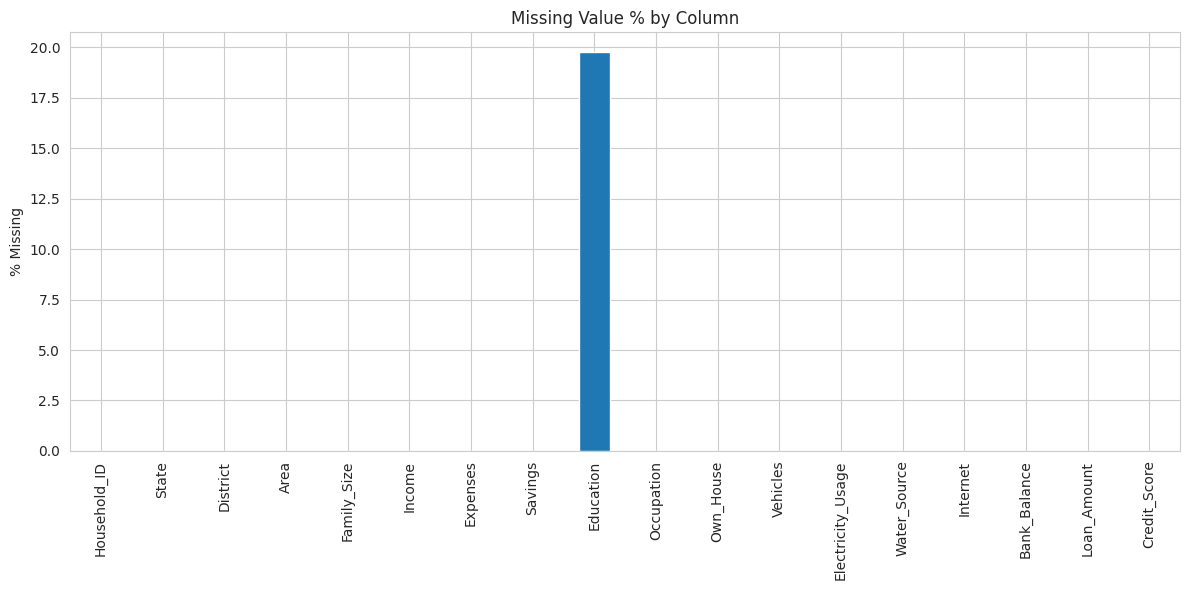

In [13]:
# Missing % nikal ke bar chart bana do
missing_percentages = (df.isnull().sum() / len(df) * 100).round(2)
missing_percentages.sort_values(ascending=False)
missing_percentages.plot(kind='bar', title='Missing Value % by Column')
plt.ylabel('% Missing')
plt.tight_layout()
plt.show()

In [14]:
# ---------- Phase 4: Duplicates ----------
print(df.duplicated().sum())
duplicate_percentage = (df.duplicated().sum() / len(df) * 100).round(2)
print(duplicate_percentage)
df[df.duplicated(keep=False)]

0
0.0


,Household_ID,State,District,Area,Family_Size,Income,Expenses,Savings,Education,Occupation,Own_House,Vehicles,Electricity_Usage,Water_Source,Internet,Bank_Balance,Loan_Amount,Credit_Score


In [15]:
# ---------- Phase 5: Unique Values ----------
df.nunique()
df.nunique().sort_values()

Area                    2
Own_House               2
Internet                2
District                4
Education               4
Water_Source            4
Vehicles                5
State                   6
Occupation              7
Family_Size            10
Credit_Score          593
Electricity_Usage    2177
Savings              2472
Income               2484
Expenses             2491
Household_ID         2500
Bank_Balance         2500
Loan_Amount          2500
dtype: int64

In [16]:
# ---------- Phase 6: Data Quality Summary Table ----------
data_quality_summary = {
    'Missing Values': df.isnull().sum(),
    'Missing Values Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Duplicate Rows': df.duplicated().sum(),
    'Duplicate Rows Percentage': (df.duplicated().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique(),
    'Data Types': df.dtypes
}
data_quality_summary_df = pd.DataFrame(data_quality_summary)
data_quality_summary_df

,Missing Values,Missing Values Percentage,Duplicate Rows,Duplicate Rows Percentage,Unique Values,Data Types
Household_ID,0,0.00,0,0.0,2500,str
State,0,0.00,0,0.0,6,str
District,0,0.00,0,0.0,4,str
Area,0,0.00,0,0.0,2,str
Family_Size,0,0.00,0,0.0,10,int64
Income,0,0.00,0,0.0,2484,int64
Expenses,0,0.00,0,0.0,2491,int64
Savings,0,0.00,0,0.0,2472,int64
Education,494,19.76,0,0.0,4,str
Occupation,0,0.00,0,0.0,7,str


In [17]:
# ---------- Phase 7: Cleaning ----------
# Working copy banate hain, original df ko chhedte nahi
df_clean = df.copy()
print(df_clean.shape)

(2500, 18)


In [18]:
# Duplicate rows hatao
df_clean.drop_duplicates(inplace=True)
print(df_clean.shape)

(2500, 18)


In [19]:
# Sirf 'Education' column mein missing values hain (494)
# Text/category column hai, isliye mode (sabse common value) se fill karenge
most_frequent_education = df_clean['Education'].mode()[0]
df_clean['Education'] = df_clean['Education'].fillna(most_frequent_education)

In [20]:
# Ab dubara check kar lo ki missing values khatam ho gaye
df_clean.isnull().sum()

Household_ID         0
State                0
District             0
Area                 0
Family_Size          0
Income               0
Expenses             0
Savings              0
Education            0
Occupation           0
Own_House            0
Vehicles             0
Electricity_Usage    0
Water_Source         0
Internet             0
Bank_Balance         0
Loan_Amount          0
Credit_Score         0
dtype: int64

In [21]:
# Cleaning se pehle vs baad comparison
cleaning_summary = {
    'Original Rows': len(df),
    'Cleaned Rows': len(df_clean),
    'Missing Values Fixed': df.isnull().sum().sum() - df_clean.isnull().sum().sum(),
    'Duplicate Rows Removed': df.duplicated().sum() - df_clean.duplicated().sum(),
}
cleaning_summary_df = pd.DataFrame(cleaning_summary, index=['Value'])
cleaning_summary_df

,Original Rows,Cleaned Rows,Missing Values Fixed,Duplicate Rows Removed
Value,2500,2500,494,0


In [22]:
# ==========================================================
# Phase 8: Univariate Analysis (ek-ek numeric column dekhna)
# ==========================================================
numeric_cols_to_plot = ['Family_Size', 'Income', 'Expenses', 'Savings',
                         'Vehicles', 'Electricity_Usage', 'Bank_Balance',
                         'Loan_Amount', 'Credit_Score']

count    2500.000000
mean        5.559600
std         2.866799
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Family_Size, dtype: float64


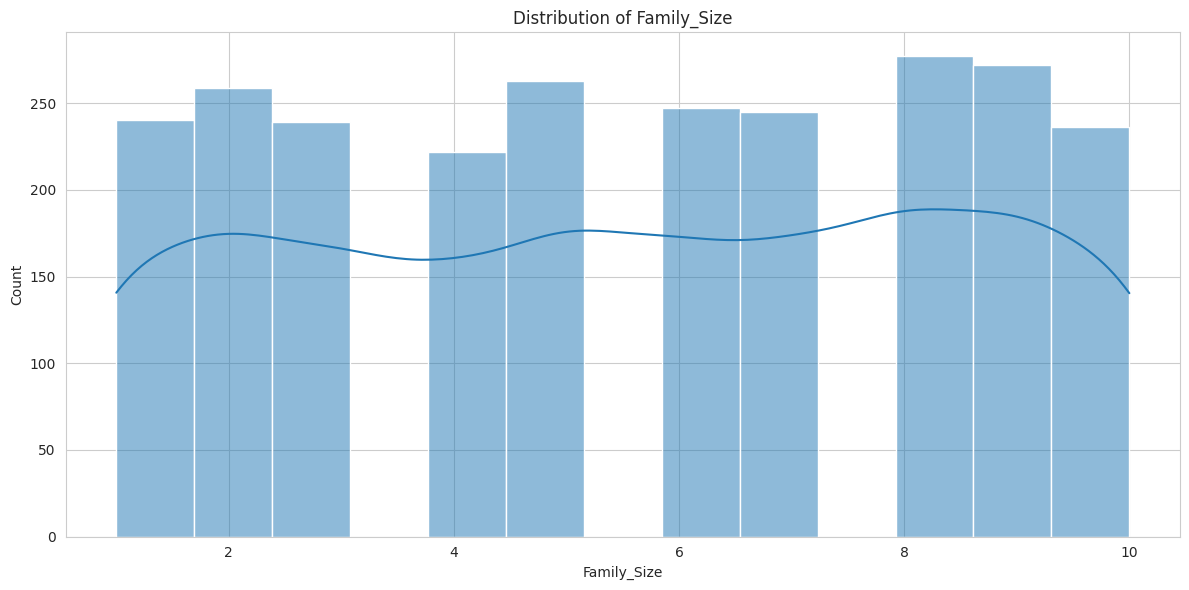

count      2500.000000
mean     152632.144800
std       85188.611366
min        5029.000000
25%       77729.250000
50%      151575.500000
75%      227428.000000
max      299997.000000
Name: Income, dtype: float64


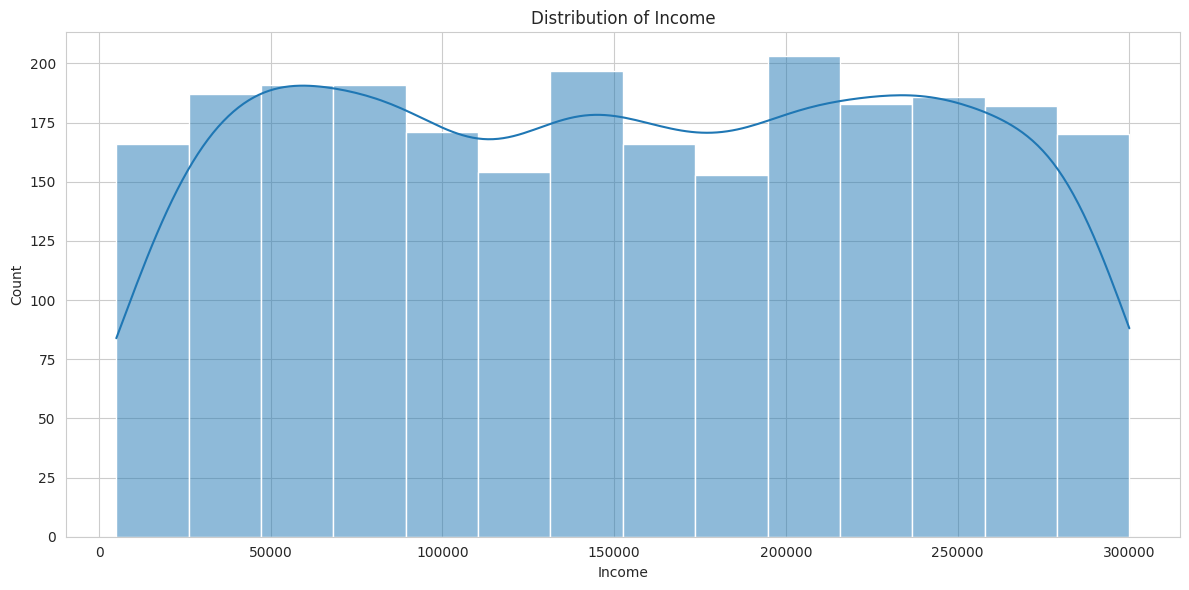

count      2500.000000
mean     115350.834400
std       73988.268729
min        2551.000000
25%       54422.750000
50%      105172.500000
75%      164802.500000
max      324505.000000
Name: Expenses, dtype: float64


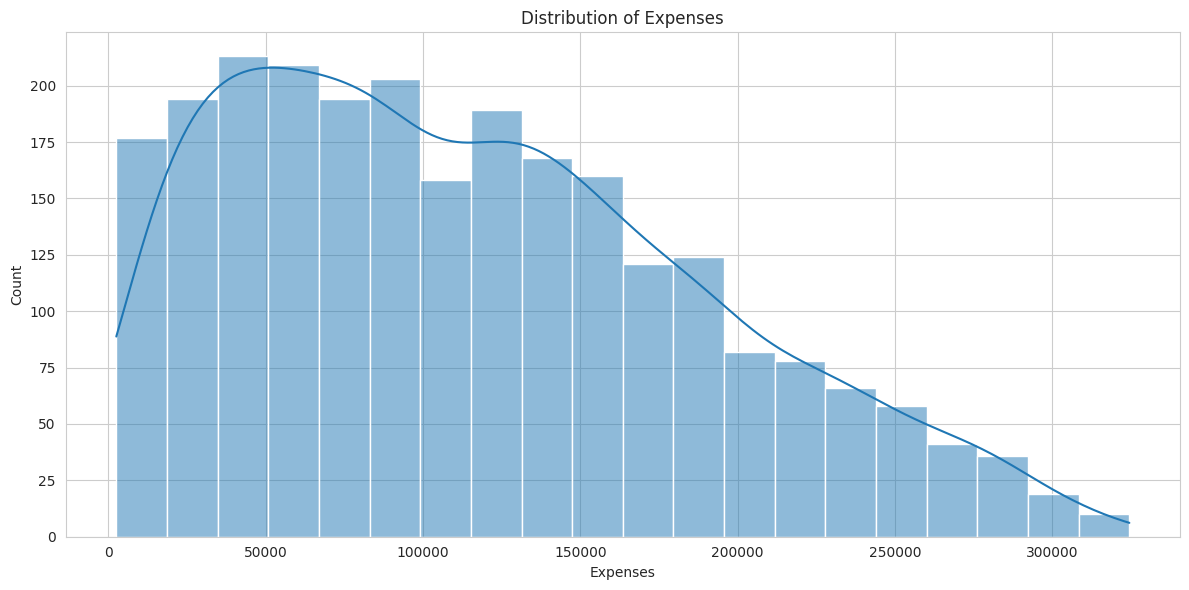

count      2500.000000
mean      37281.310400
std       40859.220528
min      -29309.000000
25%        5603.750000
50%       25474.500000
75%       61388.000000
max      174884.000000
Name: Savings, dtype: float64


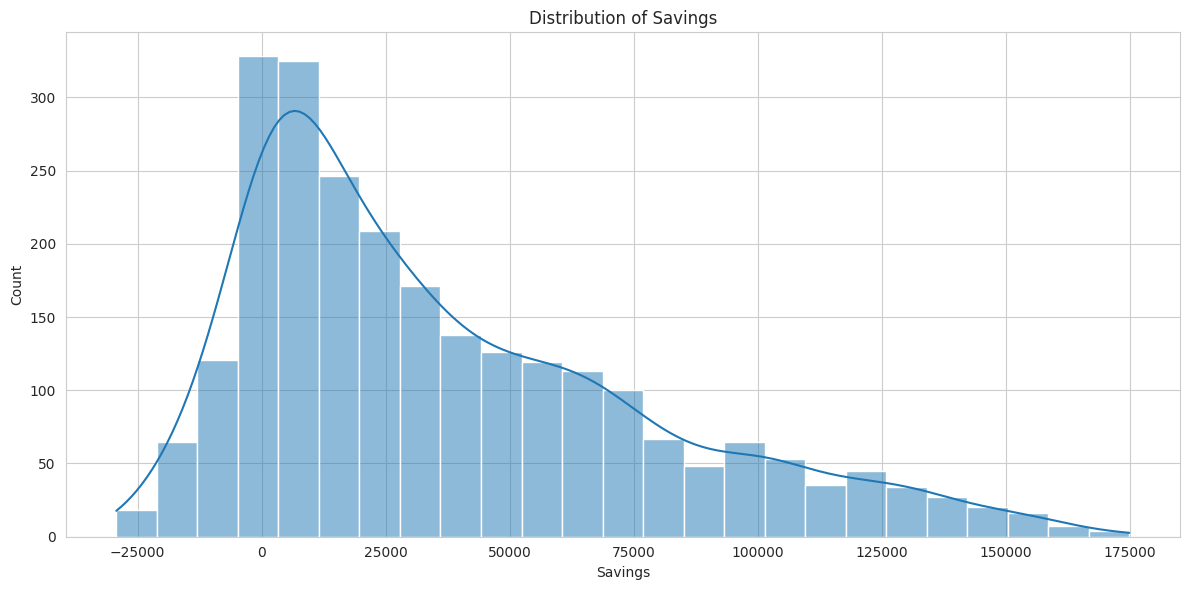

count    2500.00000
mean        2.02320
std         1.40892
min         0.00000
25%         1.00000
50%         2.00000
75%         3.00000
max         4.00000
Name: Vehicles, dtype: float64


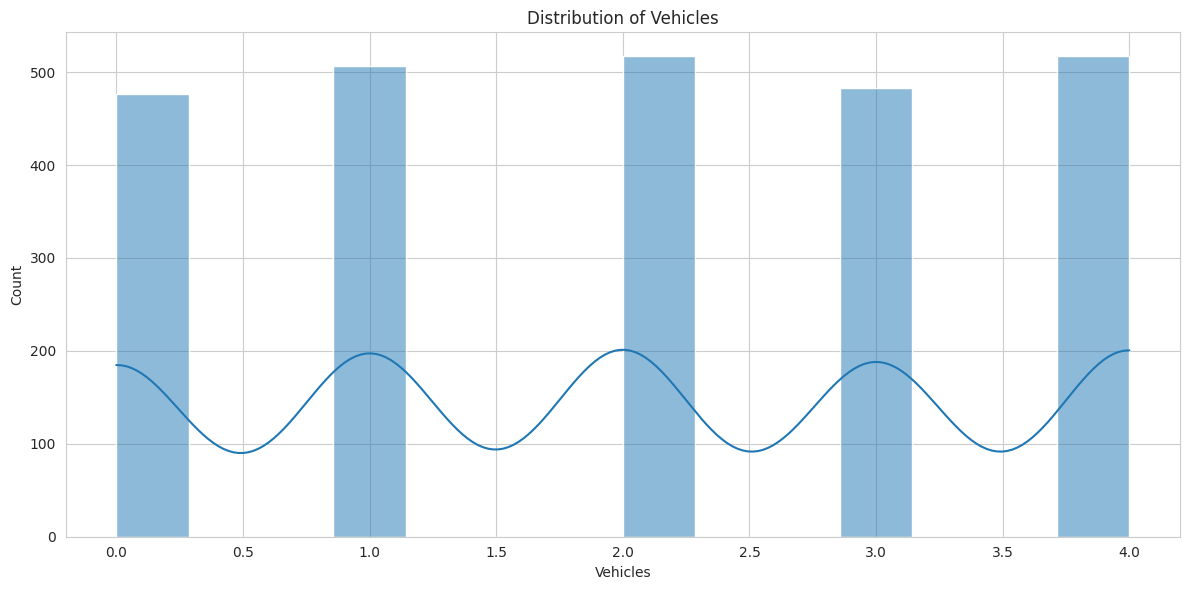

count    2500.000000
mean      462.726840
std       248.835235
min        30.600000
25%       246.225000
50%       457.050000
75%       676.650000
max       899.600000
Name: Electricity_Usage, dtype: float64


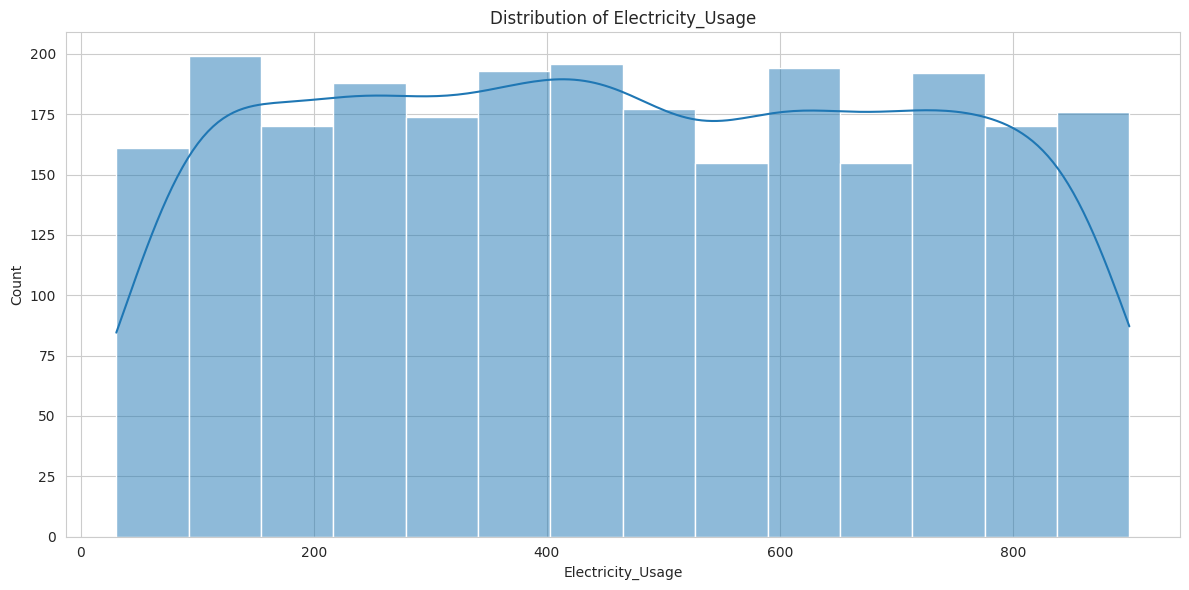

count    2.500000e+03
mean     1.023941e+06
std      5.848517e+05
min     -4.132960e+03
25%      5.118289e+05
50%      1.044039e+06
75%      1.526819e+06
max      1.999715e+06
Name: Bank_Balance, dtype: float64


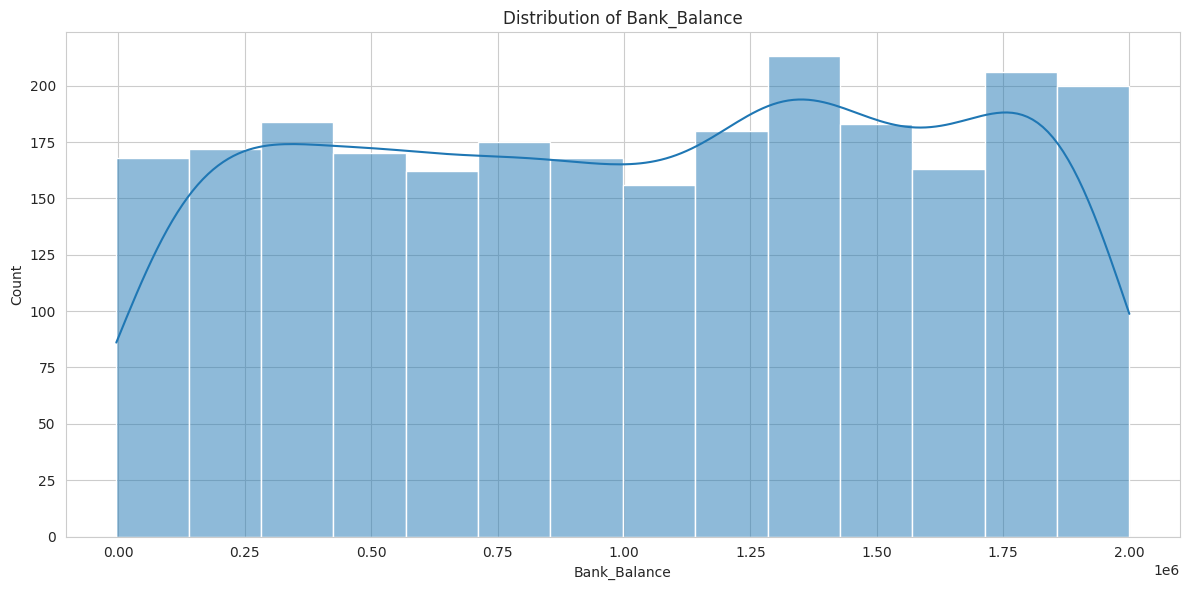

count    2.500000e+03
mean     7.520393e+05
std      4.298857e+05
min      5.633500e+02
25%      3.873788e+05
50%      7.424033e+05
75%      1.118598e+06
max      1.499889e+06
Name: Loan_Amount, dtype: float64


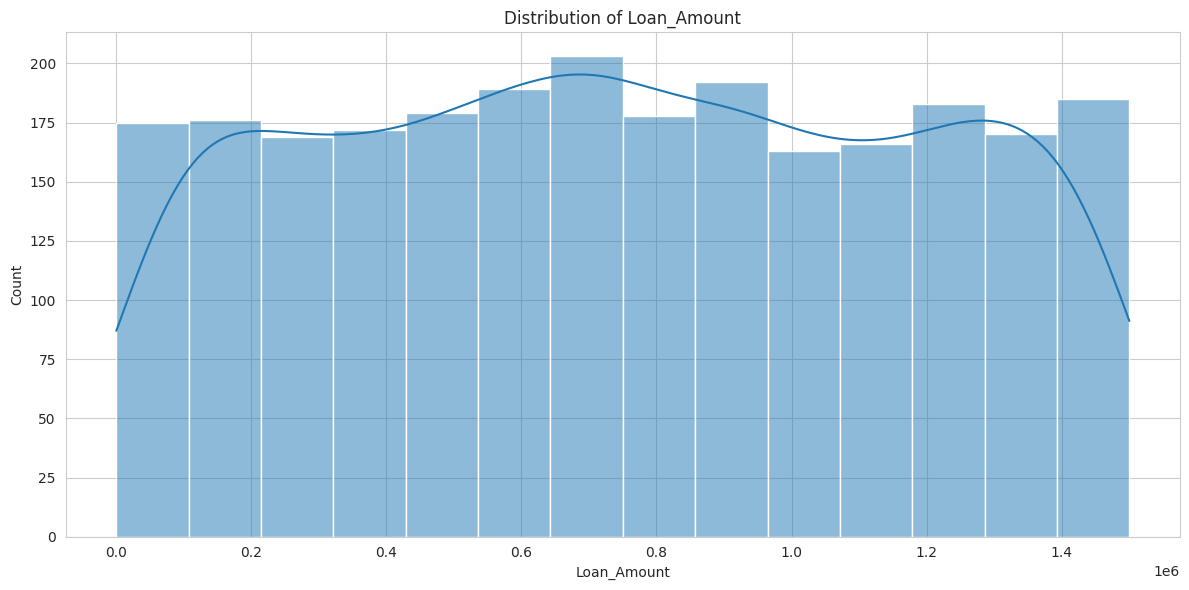

count    2500.000000
mean      599.946800
std       174.062724
min       300.000000
25%       449.000000
50%       606.500000
75%       752.000000
max       900.000000
Name: Credit_Score, dtype: float64


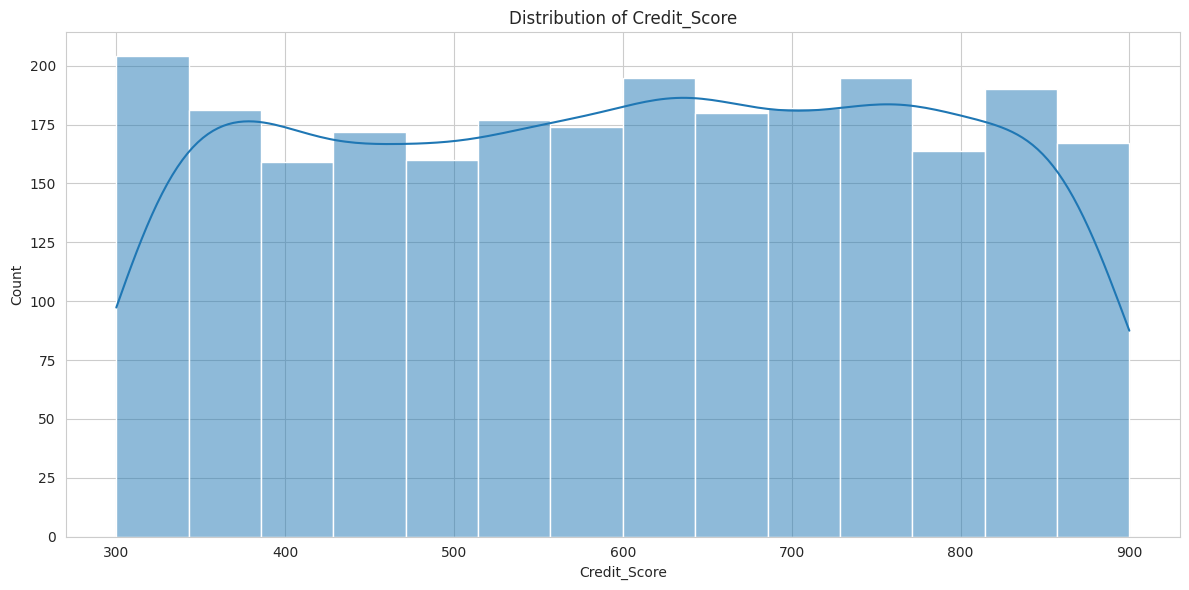

In [23]:
for col in numeric_cols_to_plot:
    print(df_clean[col].describe())
    sns.histplot(df_clean[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

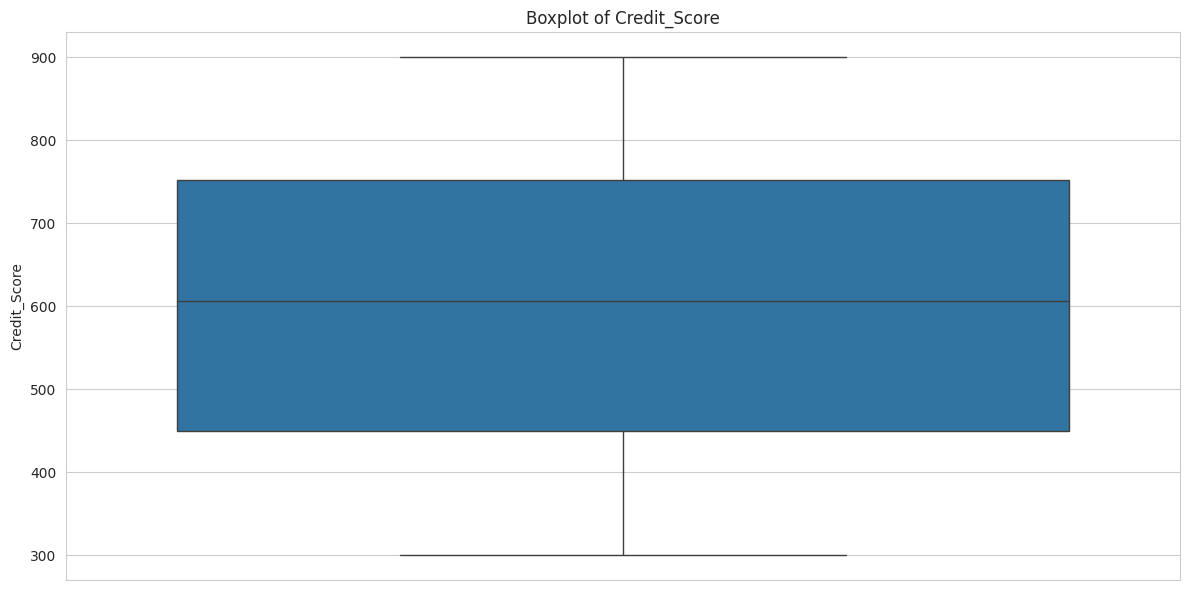

In [24]:
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_714/2267616314.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='viridis')


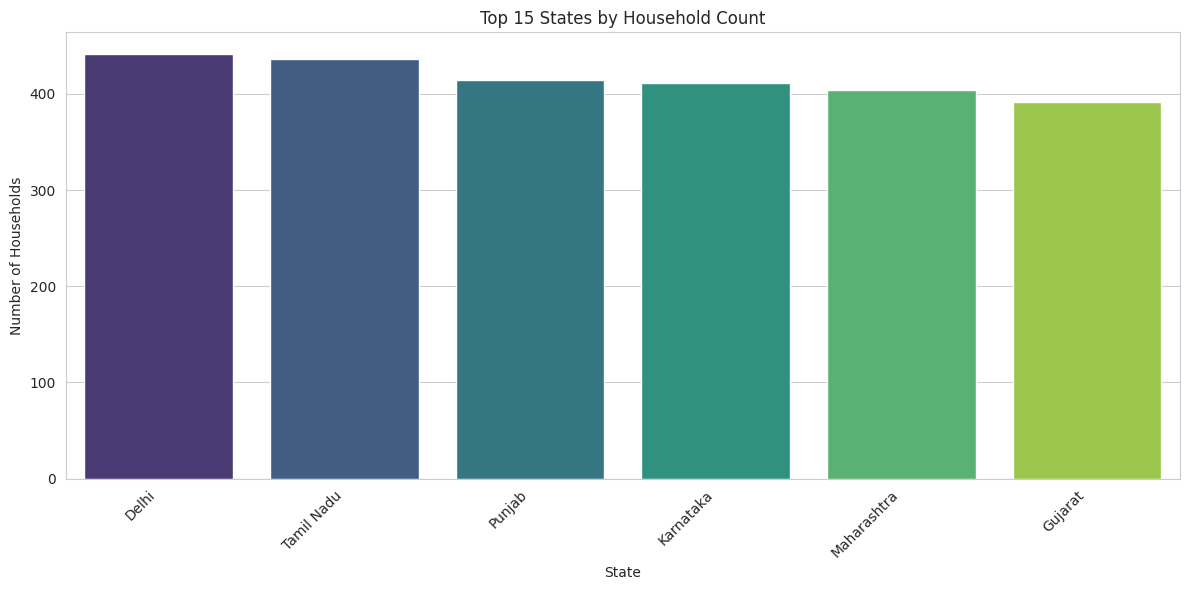

In [25]:
# ---------- Univariate Analysis: Categorical Columns ----------
# State mein bahut categories hain, isliye top 15 dikhate hain
top_states = df_clean['State'].value_counts().head(15)
sns.barplot(x=top_states.index, y=top_states.values, palette='viridis')
plt.title('Top 15 States by Household Count')
plt.xlabel('State')
plt.ylabel('Number of Households')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
categorical_cols_to_plot = ['Area', 'Education', 'Occupation', 'Own_House',
                             'Water_Source', 'Internet']

Area
Urban    1296
Rural    1204
Name: count, dtype: int64


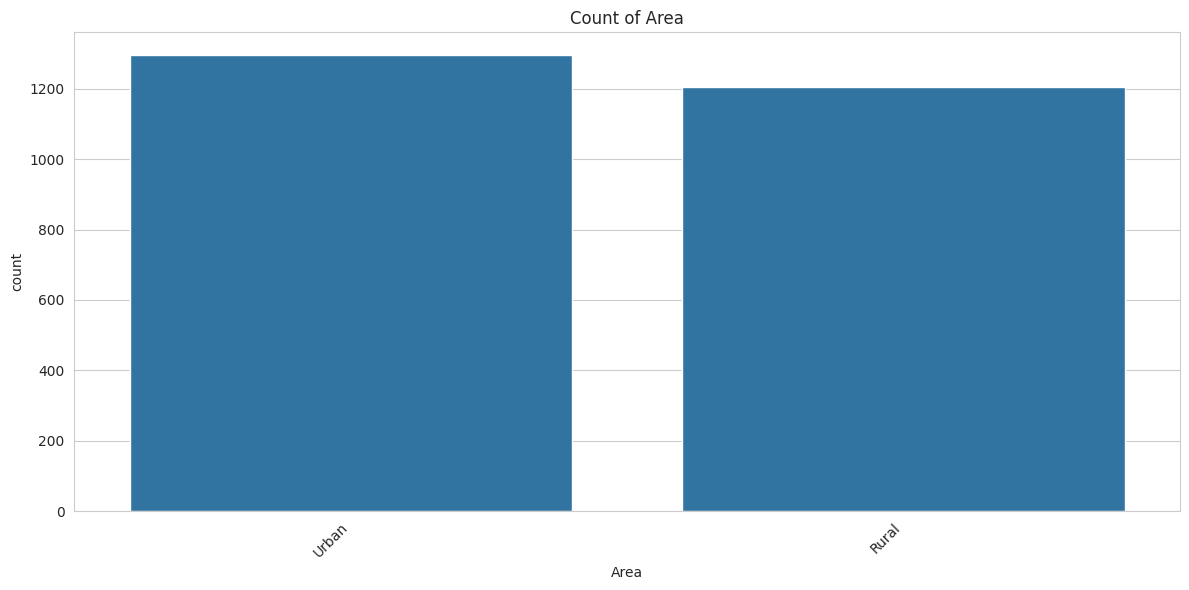

Education
Secondary       1009
Graduate         513
Primary          491
Postgraduate     487
Name: count, dtype: int64


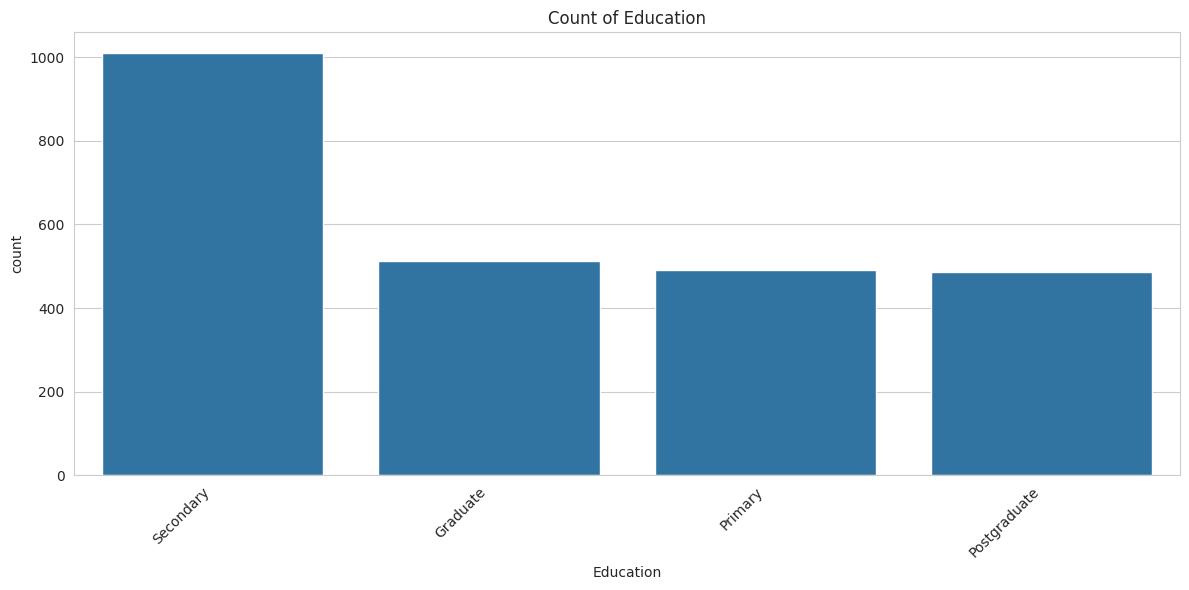

Occupation
Labor       393
Business    381
Engineer    372
Doctor      351
Farmer      342
Teacher     339
Student     322
Name: count, dtype: int64


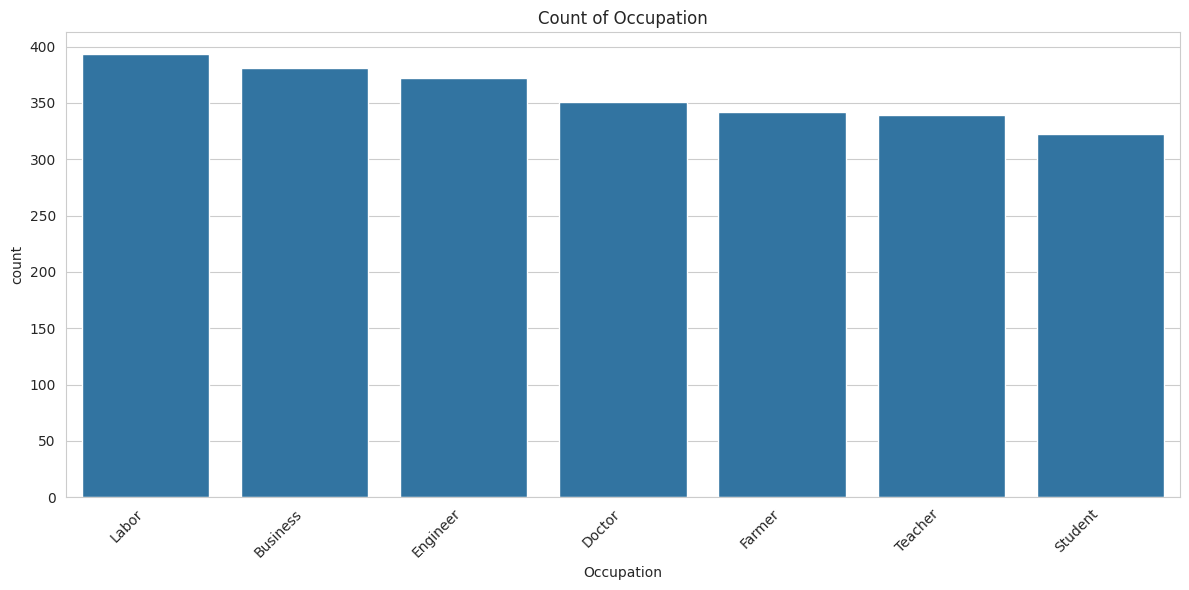

Own_House
Yes    1280
No     1220
Name: count, dtype: int64


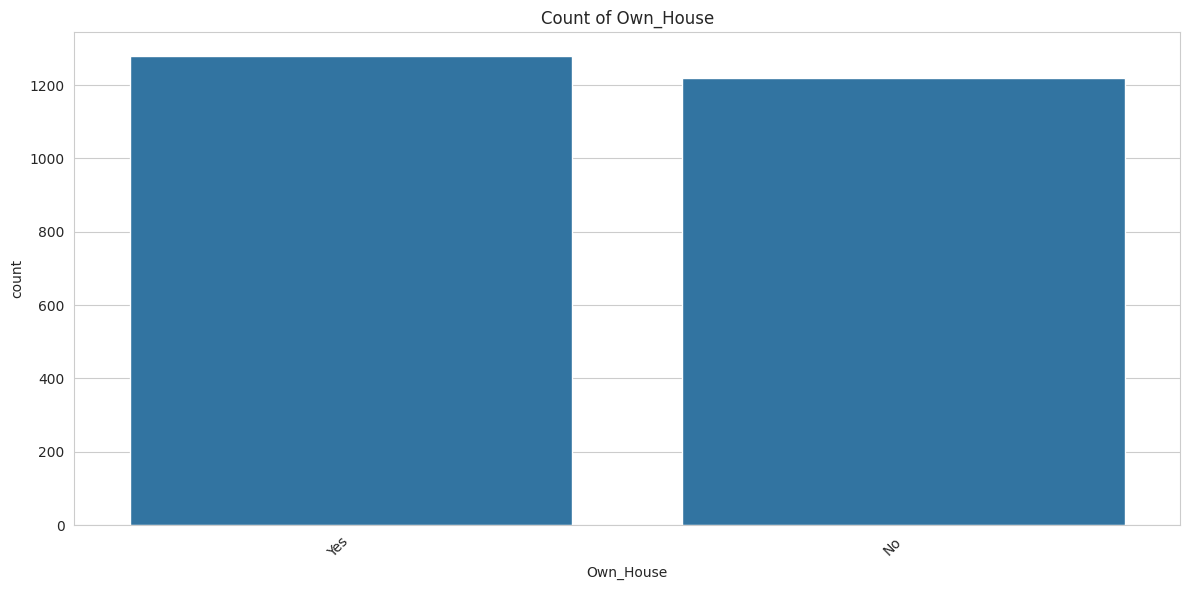

Water_Source
Well        640
Tap         631
Borewell    624
Tanker      605
Name: count, dtype: int64


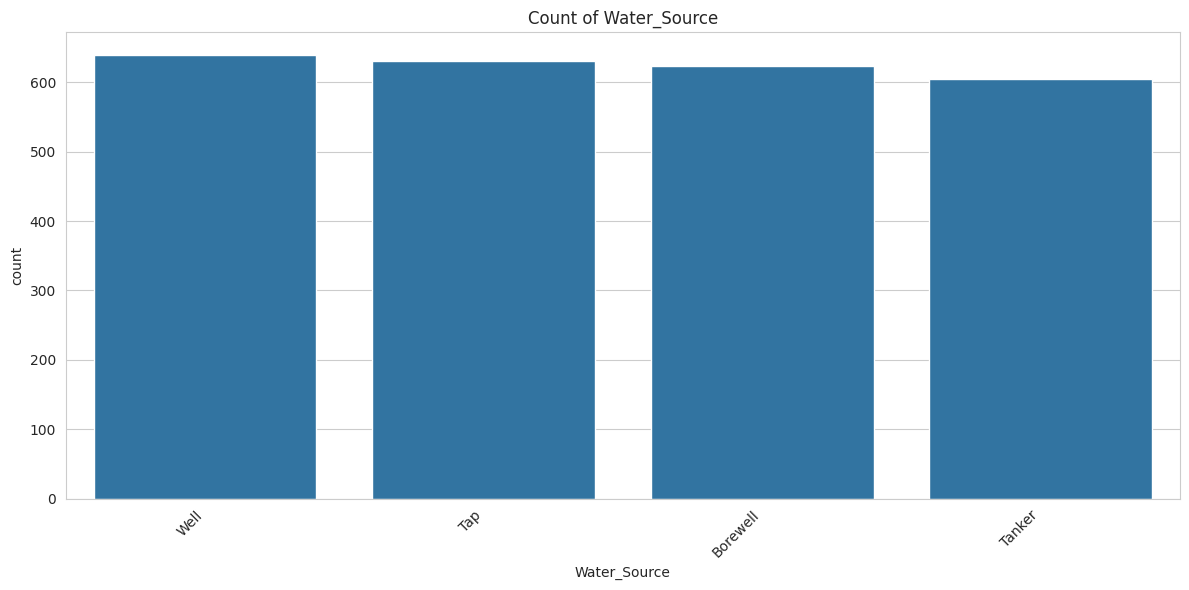

Internet
Yes    1272
No     1228
Name: count, dtype: int64


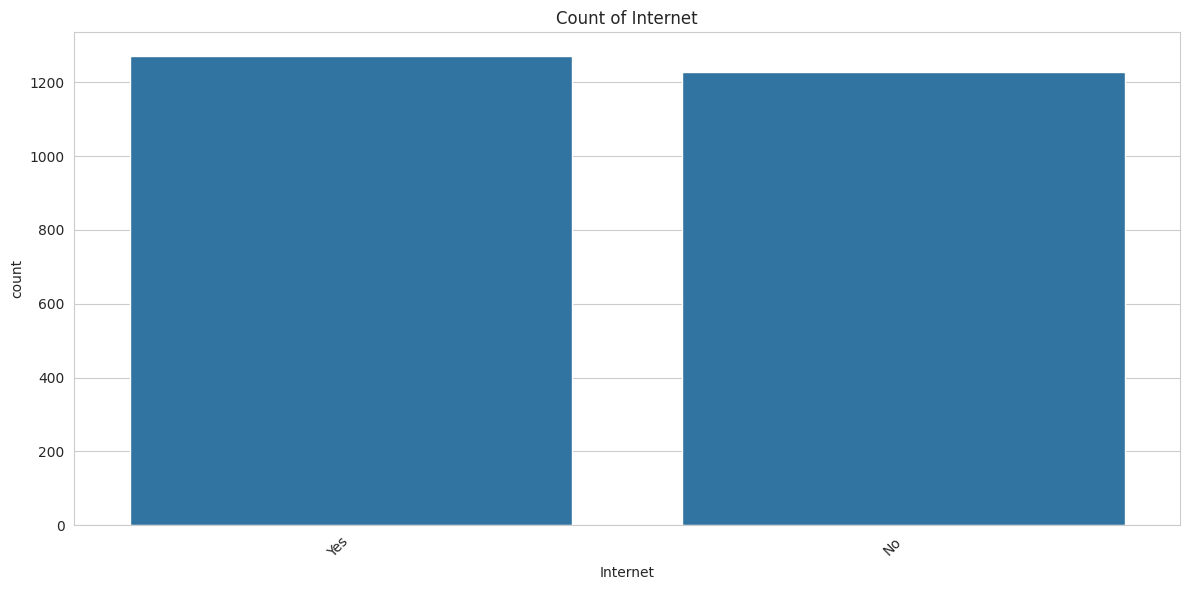

In [27]:
for col in categorical_cols_to_plot:
    print(df_clean[col].value_counts())
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [28]:
# ==========================================================
# Phase 9: Outlier Detection (IQR + Z-score method)
# ==========================================================
outlier_check_cols = ['Income', 'Expenses', 'Savings', 'Loan_Amount', 'Credit_Score']

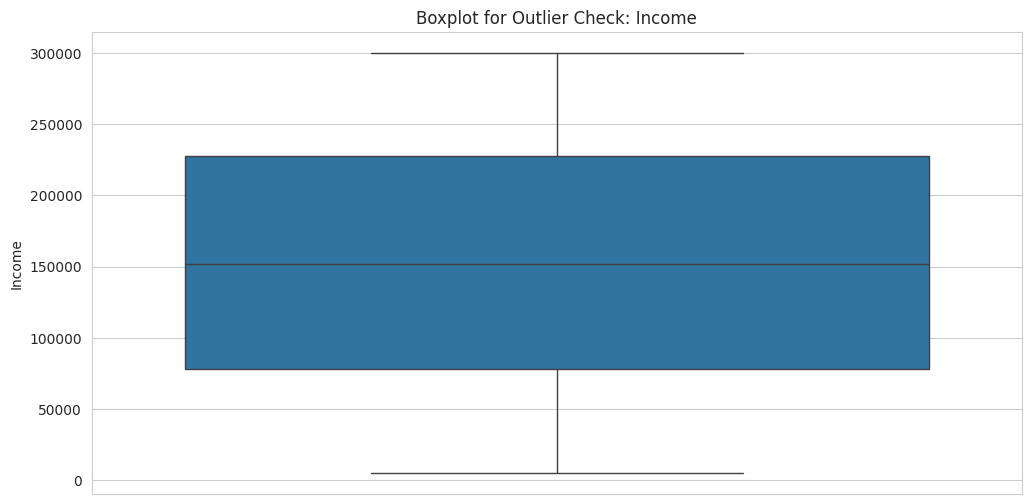

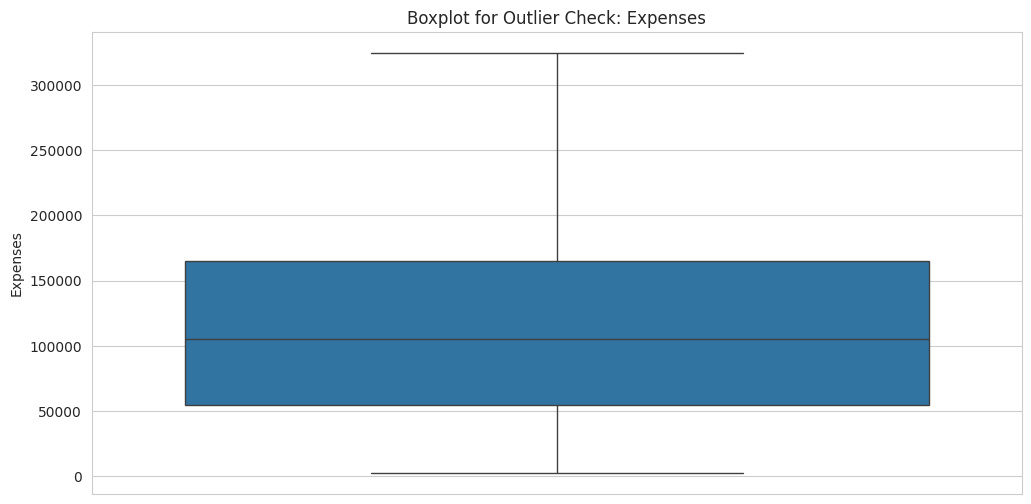

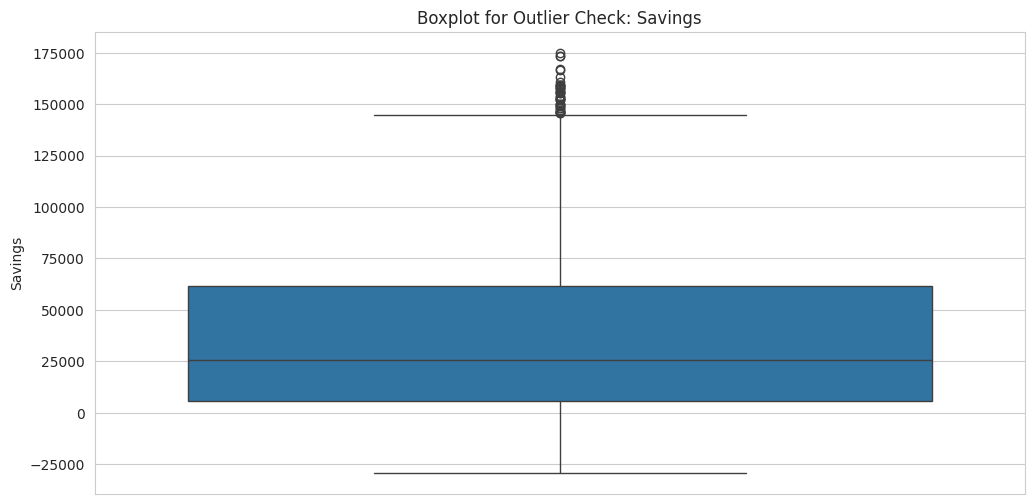

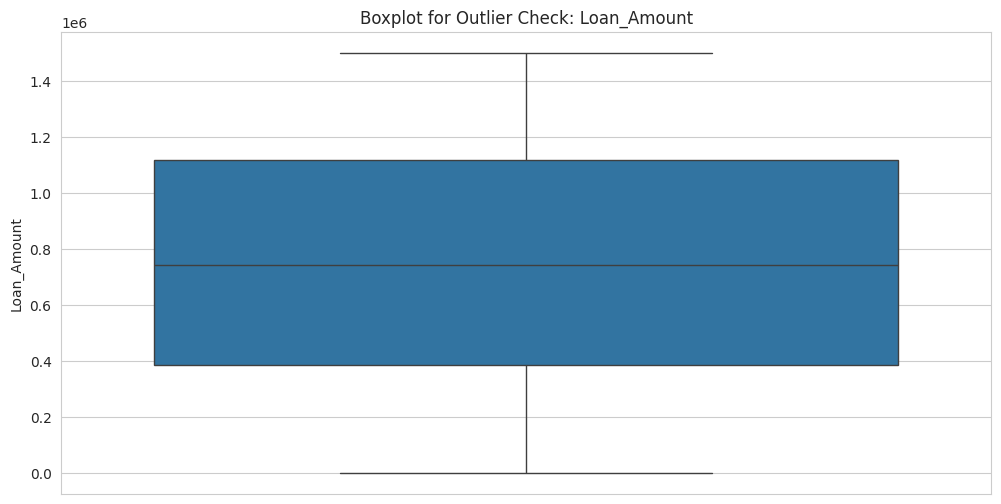

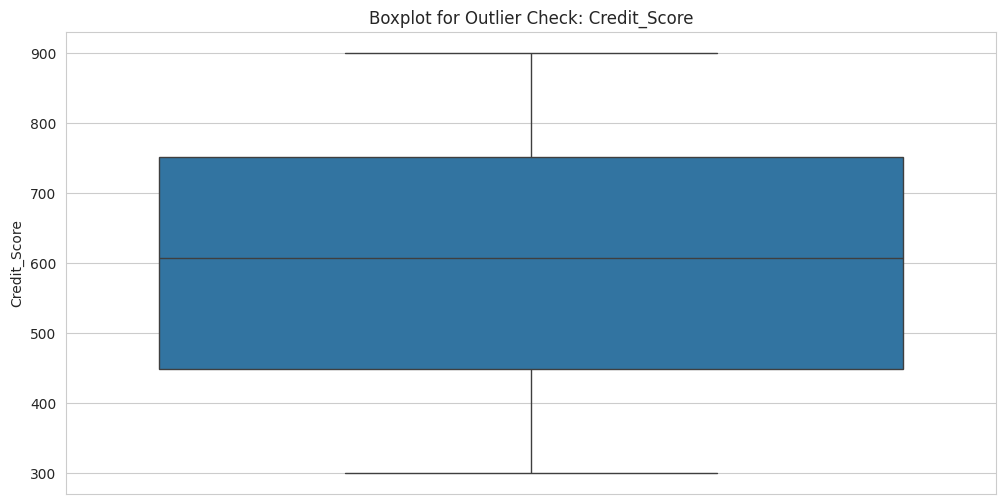

In [29]:
for col in outlier_check_cols:
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot for Outlier Check: {col}')
    plt.show()

In [30]:
    IQR = df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25)
    lower_fence = df_clean[col].quantile(0.25) - 1.5 * IQR
    upper_fence = df_clean[col].quantile(0.75) + 1.5 * IQR
    outliers_iqr = df_clean[(df_clean[col] < lower_fence) | (df_clean[col] > upper_fence)]
    print(f"{col} - Outliers using IQR method:", len(outliers_iqr))

Credit_Score - Outliers using IQR method: 0


In [31]:
    z_scores = stats.zscore(df_clean[col])
    outliers_zscore = df_clean[np.abs(z_scores) > 3]
    print(f"{col} - Outliers using Z-score method:", len(outliers_zscore))

Credit_Score - Outliers using Z-score method: 0


In [32]:
# ==========================================================
# Phase 10: Bivariate Analysis (do columns ka relationship)
# ==========================================================

In [33]:
# Income vs Education
print(df_clean.groupby('Education')['Income'].mean())

Education
Graduate        156123.801170
Postgraduate    153965.540041
Primary         150495.152749
Secondary       151253.234886
Name: Income, dtype: float64


/tmp/ipykernel_714/2098014644.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='Income', data=df_clean, palette='pastel')


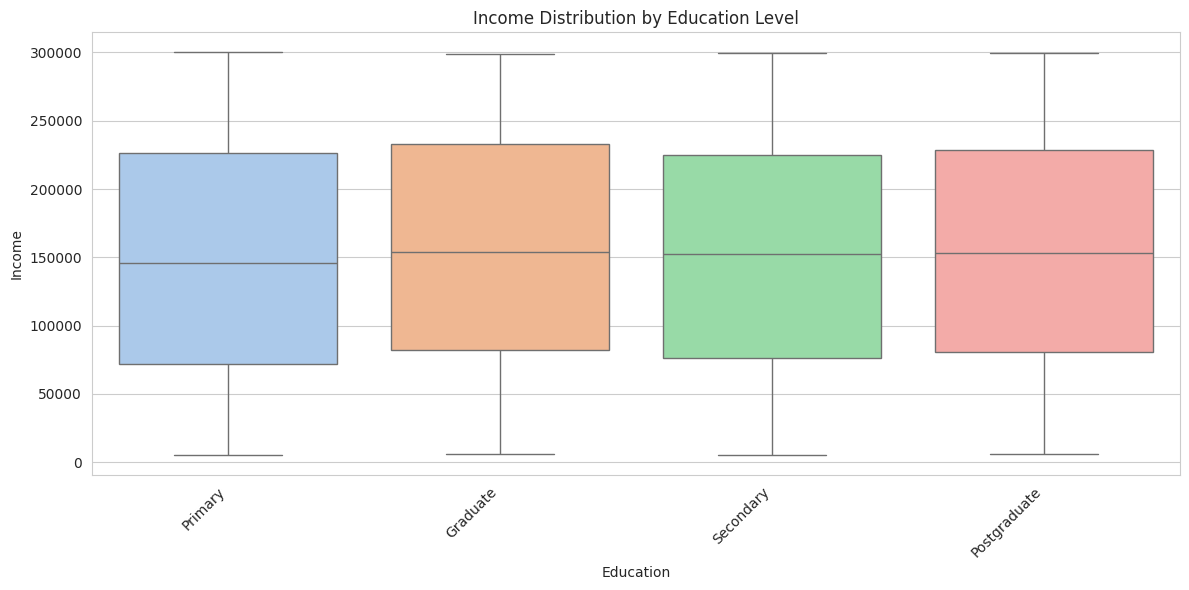

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education', y='Income', data=df_clean, palette='pastel')
plt.title('Income Distribution by Education Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_714/3491693100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education', y='Income', data=df_clean, errorbar=None, palette='mako')


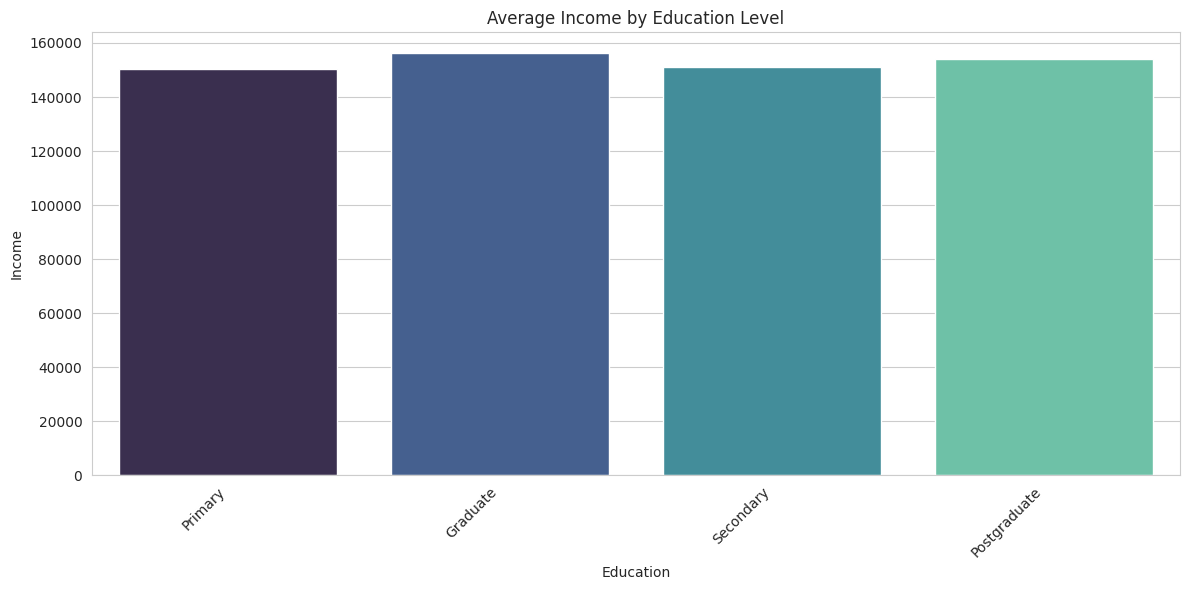

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Education', y='Income', data=df_clean, errorbar=None, palette='mako')
plt.title('Average Income by Education Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
# Income across top 15 states (Occupation ke hisab se hue for color)
plt.figure(figsize=(20, 10))
top_15_states = df_clean['State'].value_counts().head(15).index.tolist()
df_top_states = df_clean[df_clean['State'].isin(top_15_states)]

<Figure size 2000x1000 with 0 Axes>

/tmp/ipykernel_714/1644868880.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_states, x='State', y='Income', order=top_15_states, palette='viridis')


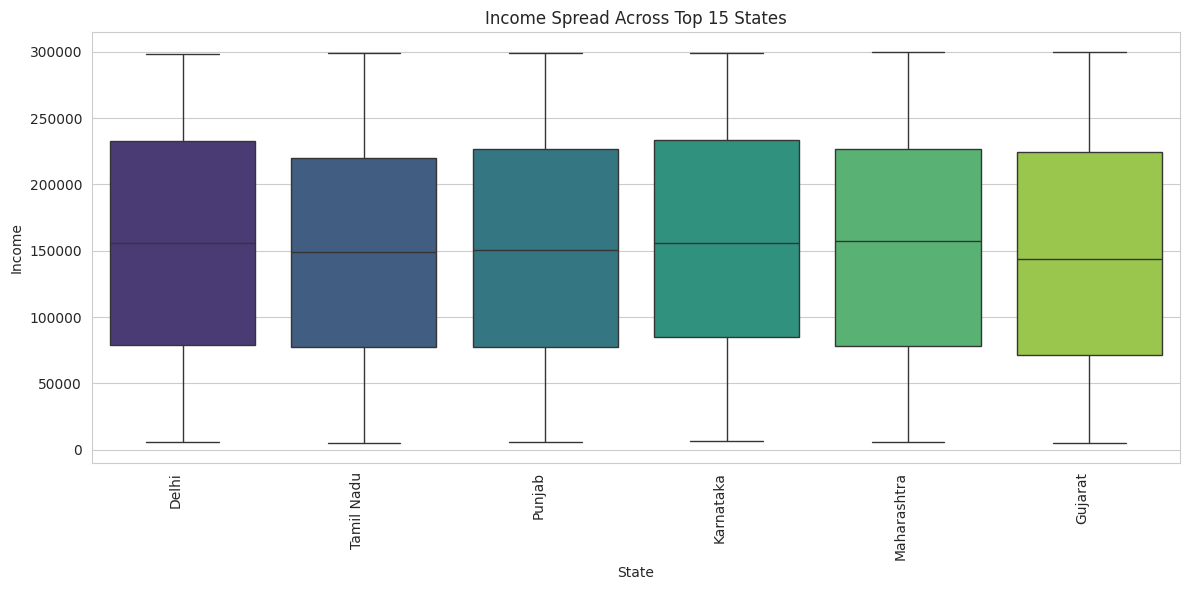

In [37]:
sns.boxplot(data=df_top_states, x='State', y='Income', order=top_15_states, palette='viridis')
plt.title('Income Spread Across Top 15 States')
plt.xlabel('State')
plt.ylabel('Income')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

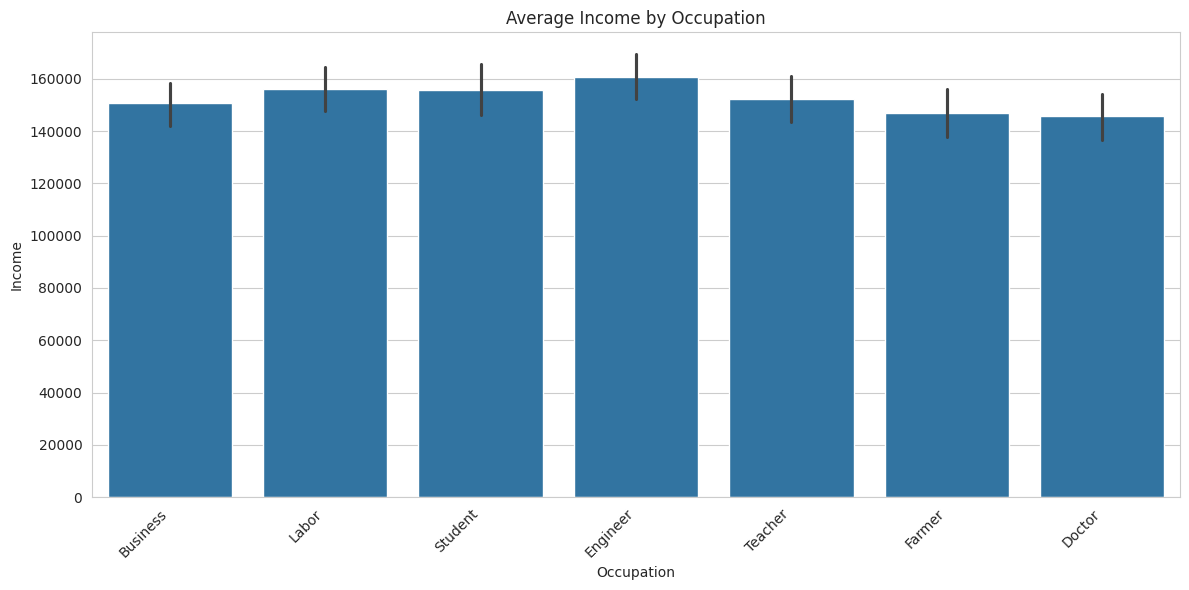

In [38]:
# Occupation vs Income
df_clean.groupby('Occupation')
sns.barplot(x='Occupation', y='Income', data=df_clean)
plt.title('Average Income by Occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

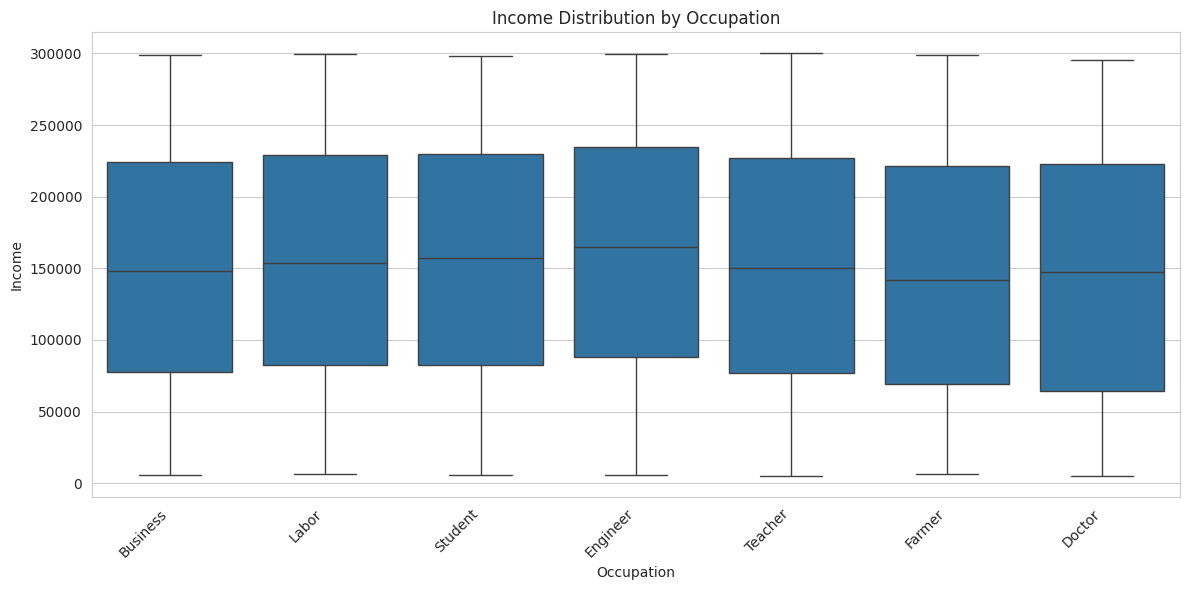

In [39]:
sns.boxplot(x='Occupation', y='Income', data=df_clean)
plt.title('Income Distribution by Occupation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

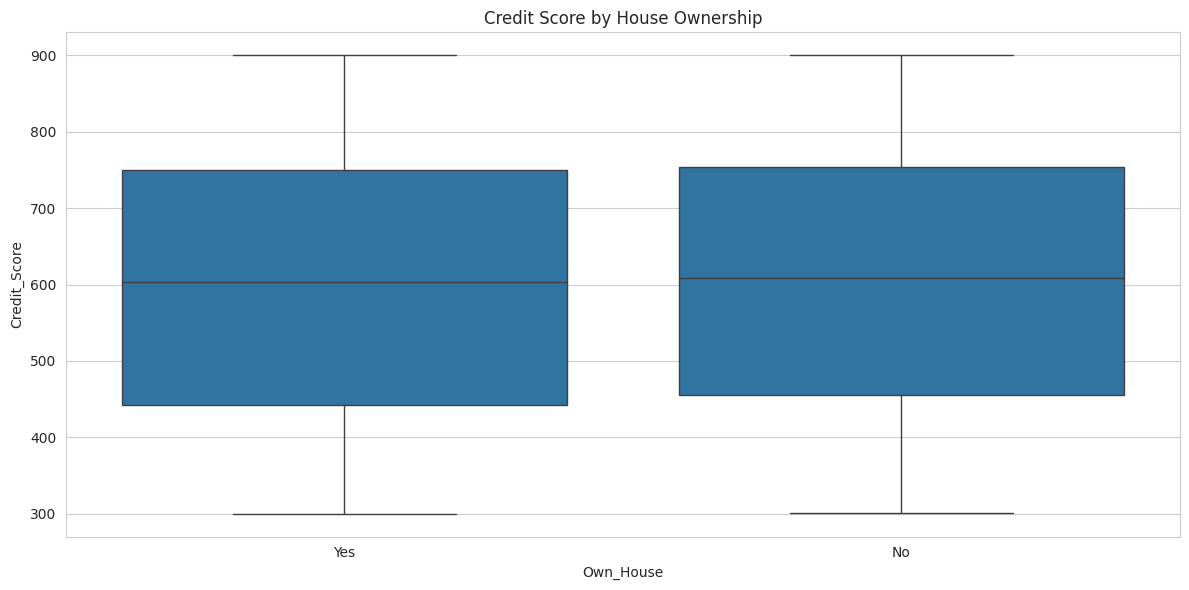

In [40]:
# Own_House vs Credit_Score
pd.crosstab(df_clean['Own_House'], df_clean['Education'], normalize='index')
sns.boxplot(x='Own_House', y='Credit_Score', data=df_clean)
plt.title('Credit Score by House Ownership')
plt.tight_layout()
plt.show()

In [41]:
# ==========================================================
# Phase 11: Heatmaps (crosstabs se pattern dekhna)
# ==========================================================

In [42]:
# Income ko 5 bins mein baant ke Education ke saath dekhte hain
bins = pd.cut(df_clean['Income'], bins=5, include_lowest=True)
heatmap_data = pd.crosstab(bins, df_clean['Education'])

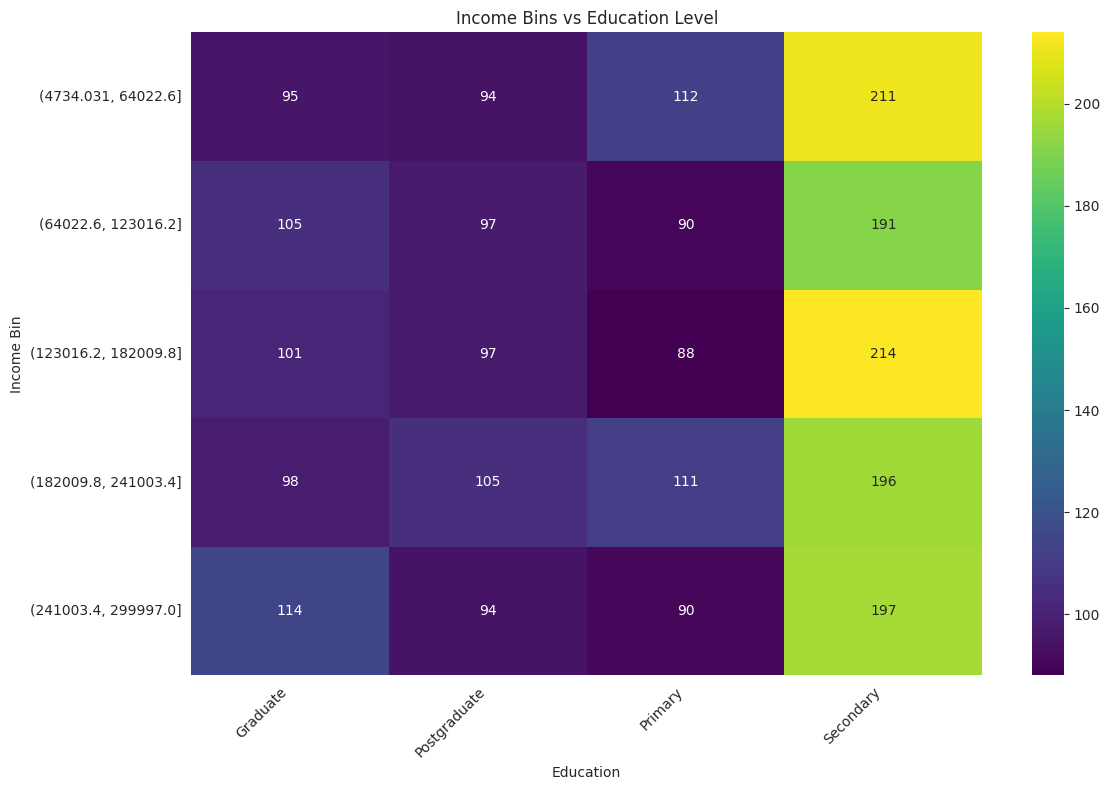

In [43]:
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis')
plt.title('Income Bins vs Education Level')
plt.xlabel('Education')
plt.ylabel('Income Bin')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
# ==========================================================
# Phase 12: Correlation Matrix
# ==========================================================
df_numeric = df_clean.select_dtypes(include=['number'])

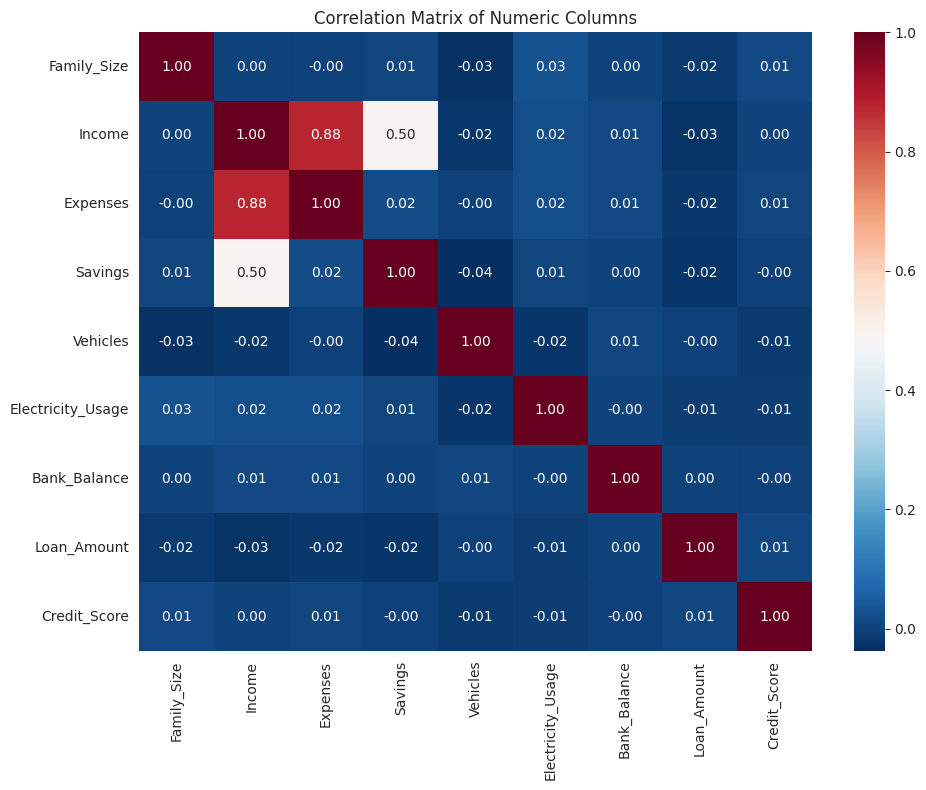

In [45]:
corr_matrix = df_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r')
plt.title('Correlation Matrix of Numeric Columns')
plt.tight_layout()
plt.show()

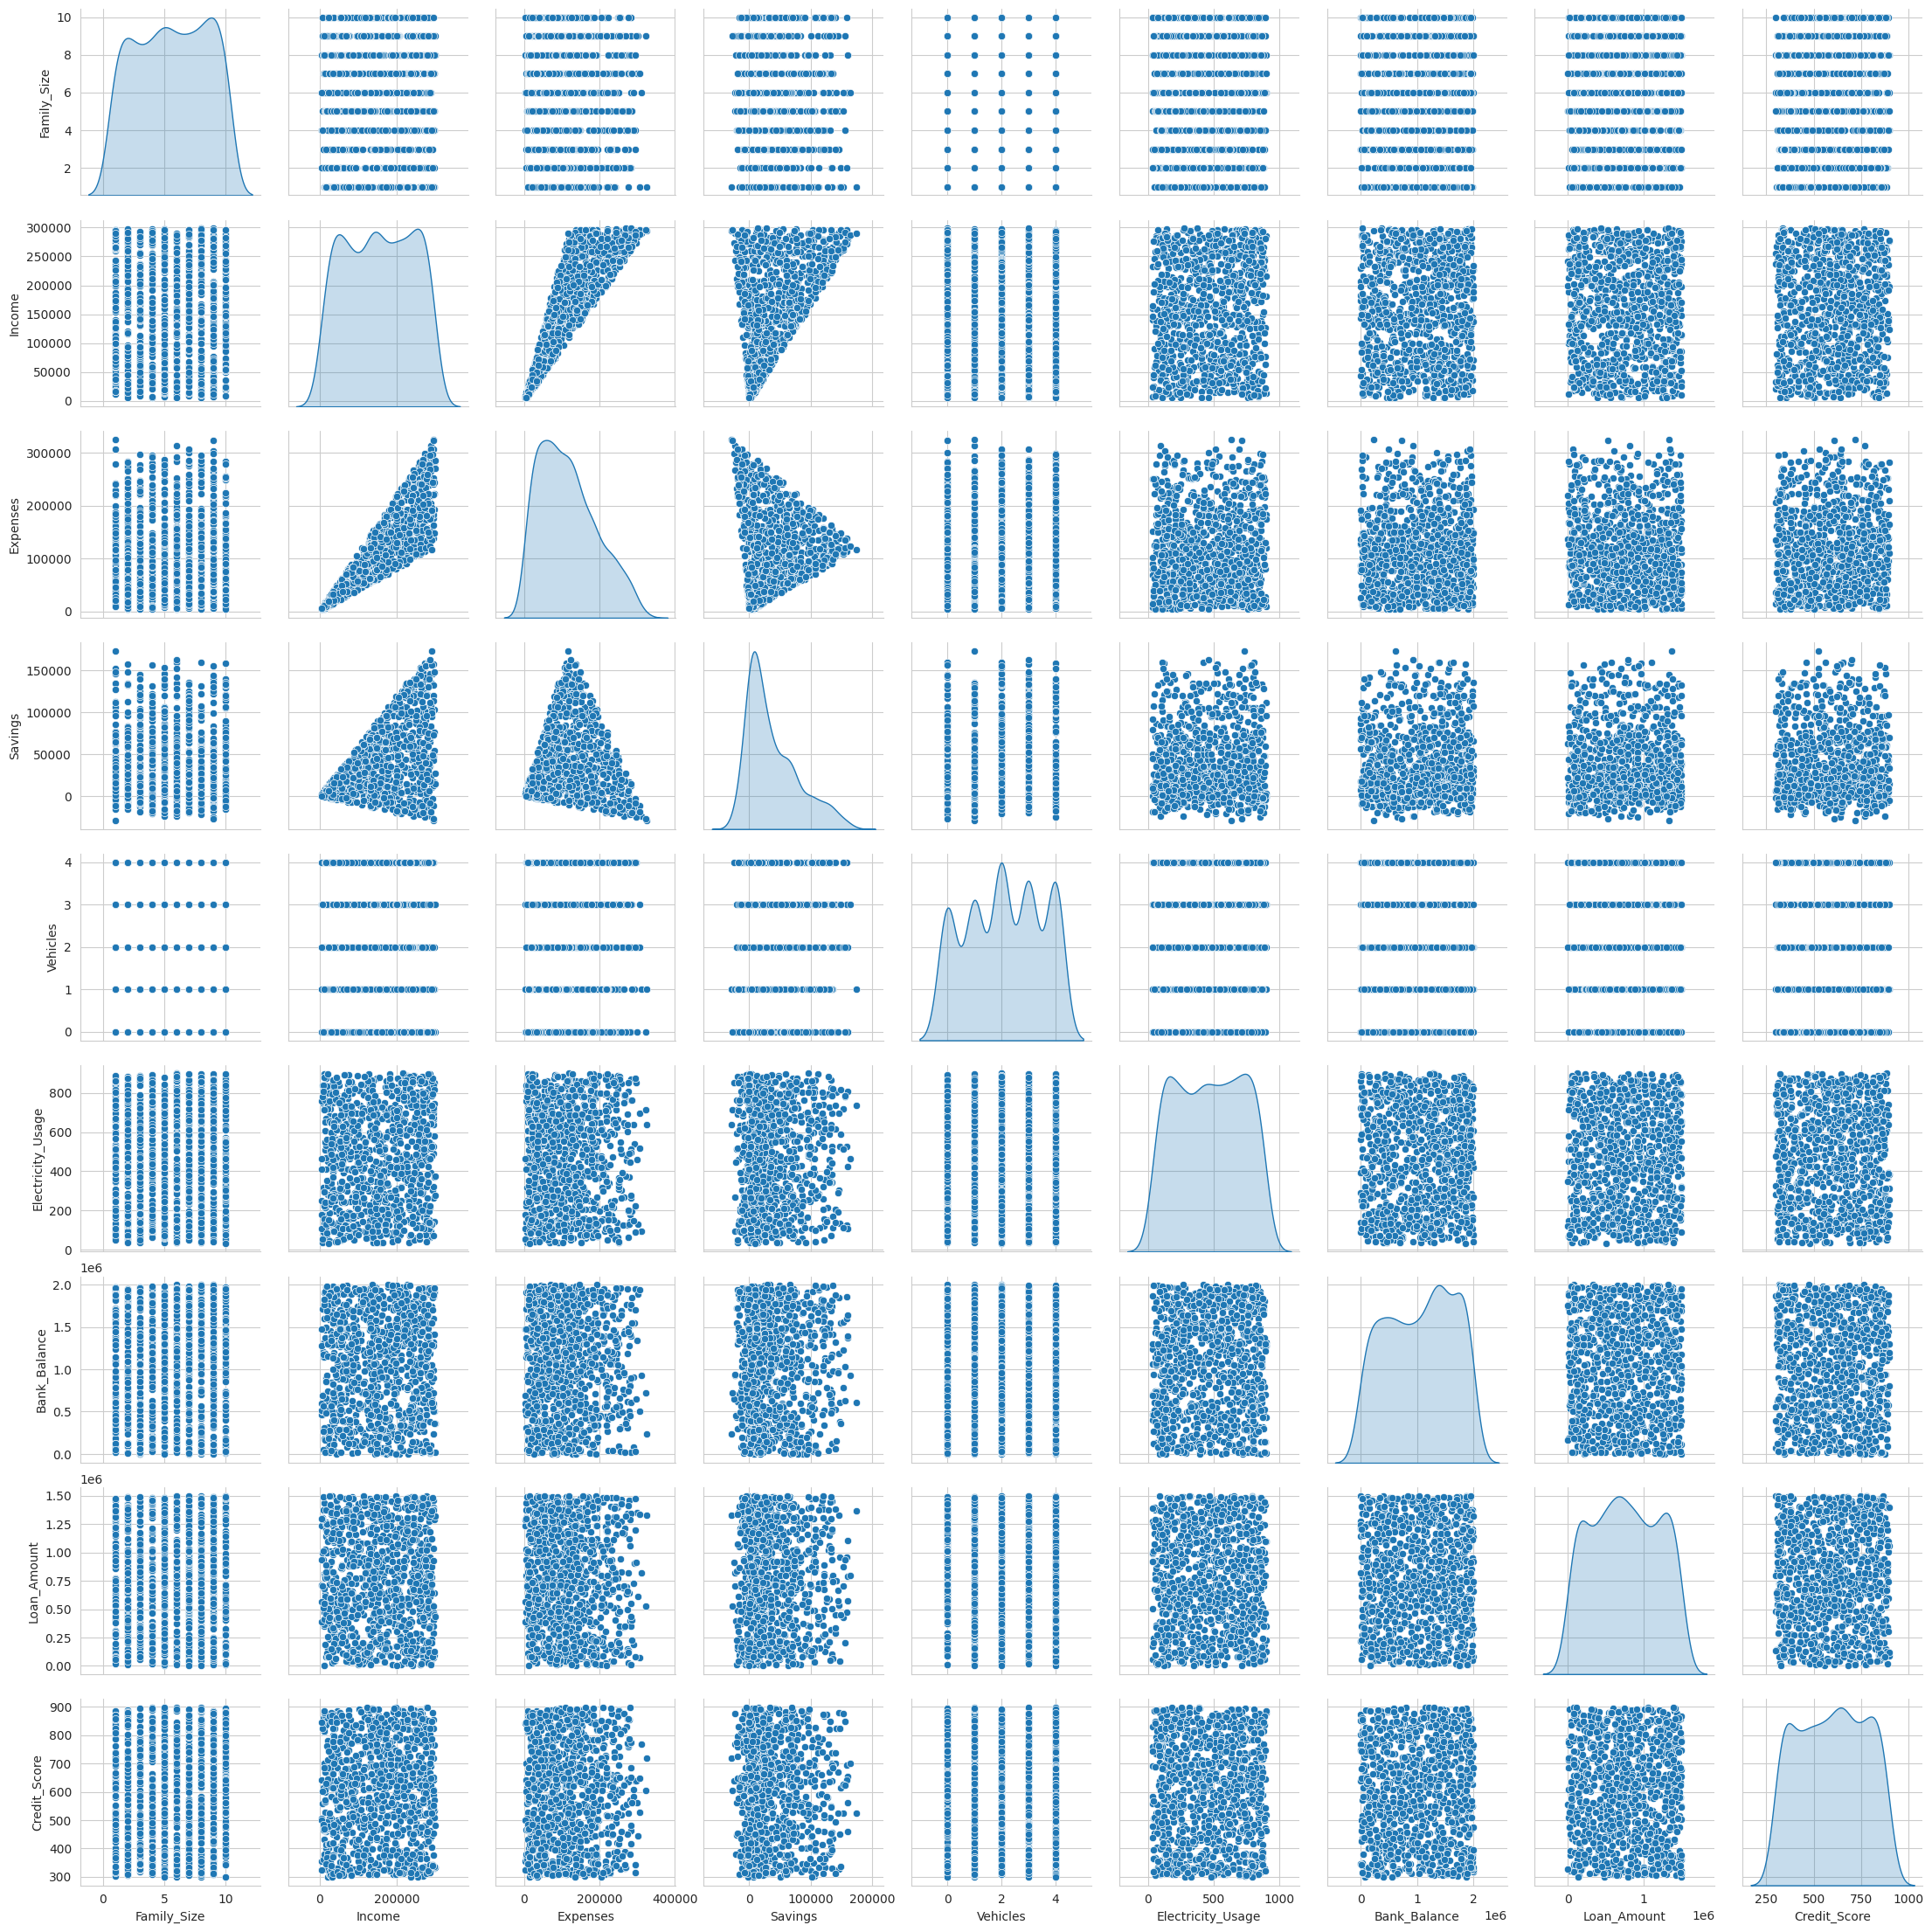

In [46]:
# Pairplot - sabhi numeric columns ek saath (thoda heavy hai, isliye sample lo agar rows zyada hon)
sns.pairplot(df_numeric.sample(min(1000, len(df_numeric)), random_state=6), diag_kind='kde')
plt.show()

In [47]:
# ==========================================================
# Phase 13: Pivot Tables
# ==========================================================
pivot_table = pd.pivot_table(df_clean, values='Income', index='State', columns='Education', aggfunc='mean')
print(pivot_table)

Education         Graduate   Postgraduate        Primary      Secondary
State                                                                  
Delhi        162080.091743  159563.811111  142392.943820  155377.928571
Gujarat      143566.973333  139065.358974  173672.392857  145838.948387
Karnataka    161115.357143  159973.612500  145103.493151  159311.425287
Maharashtra  148502.202381  155785.670886  154914.380282  151825.529412
Punjab       158131.921053  147974.750000  144212.481481  153398.067416
Tamil Nadu   160368.894118  160380.500000  143644.946237  141830.853933


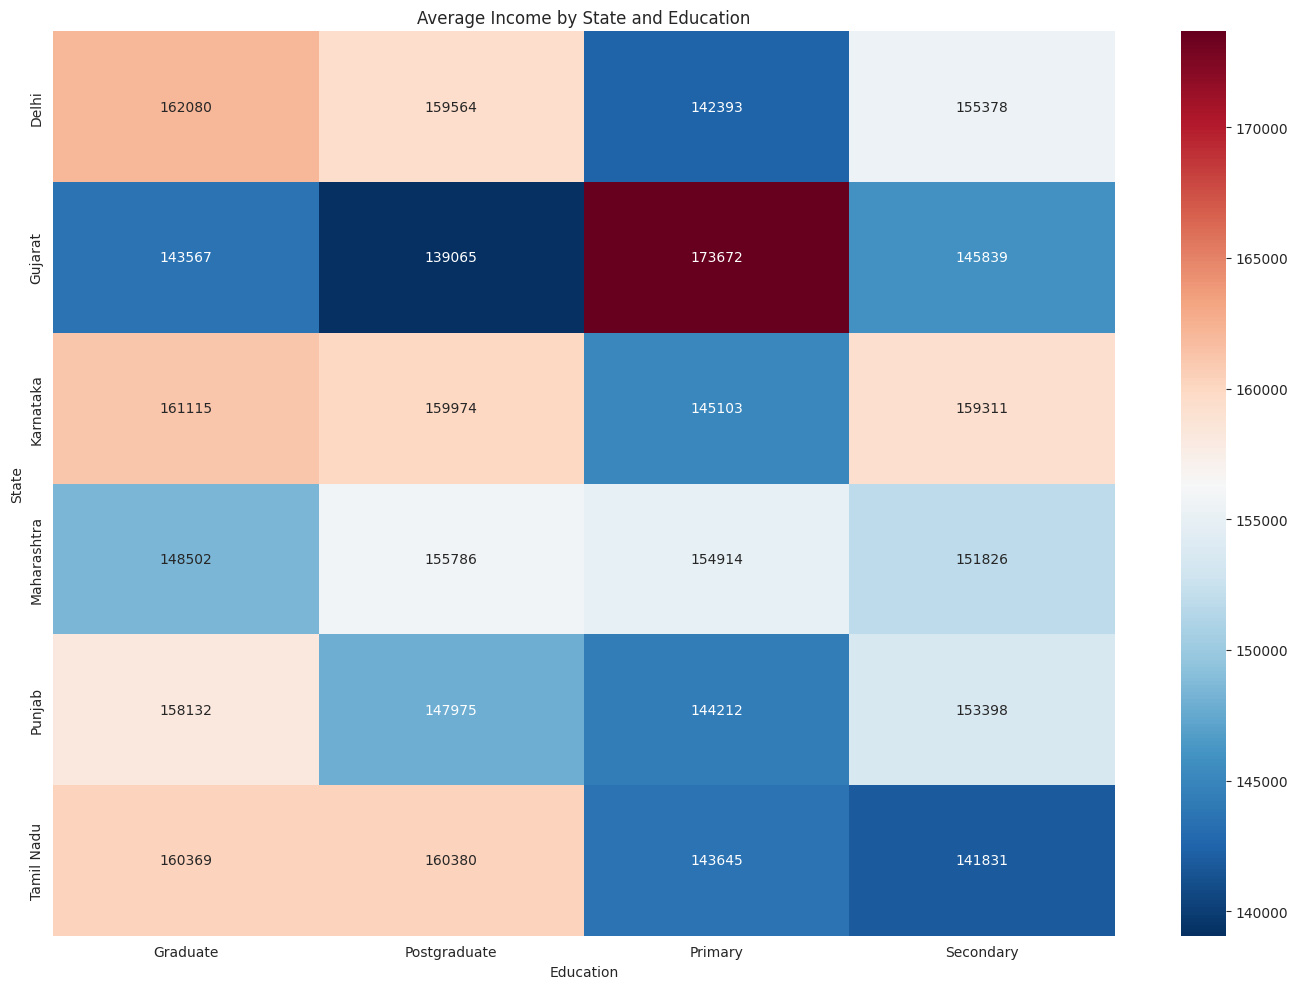

In [48]:
df_pivot = pivot_table.round(2)
plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot, annot=True, fmt='.0f', cmap='RdBu_r')
plt.title('Average Income by State and Education')
plt.tight_layout()
plt.show()

In [49]:
# ==========================================================
# Phase 14: Derived Features (naye columns banana)
# ==========================================================
# Savings Rate = Savings ka Income ke against kitna % hai
df_clean['Savings_Rate'] = (df_clean['Savings'] / df_clean['Income'] * 100).round(2)

In [50]:
# Debt to Income Ratio = Loan Amount ka Income ke against kitna % hai
df_clean['Debt_to_Income_Ratio'] = (df_clean['Loan_Amount'] / df_clean['Income'] * 100).round(2)

In [51]:
df_clean[['Savings_Rate', 'Debt_to_Income_Ratio']].describe()

,Savings_Rate,Debt_to_Income_Ratio
count,2500.000000,2500.000000
mean,24.530668,1038.574800
std,20.296947,1952.305851
min,-9.970000,0.490000
25%,6.887500,251.865000
50%,24.725000,499.270000
75%,42.110000,952.110000
max,59.980000,25754.250000


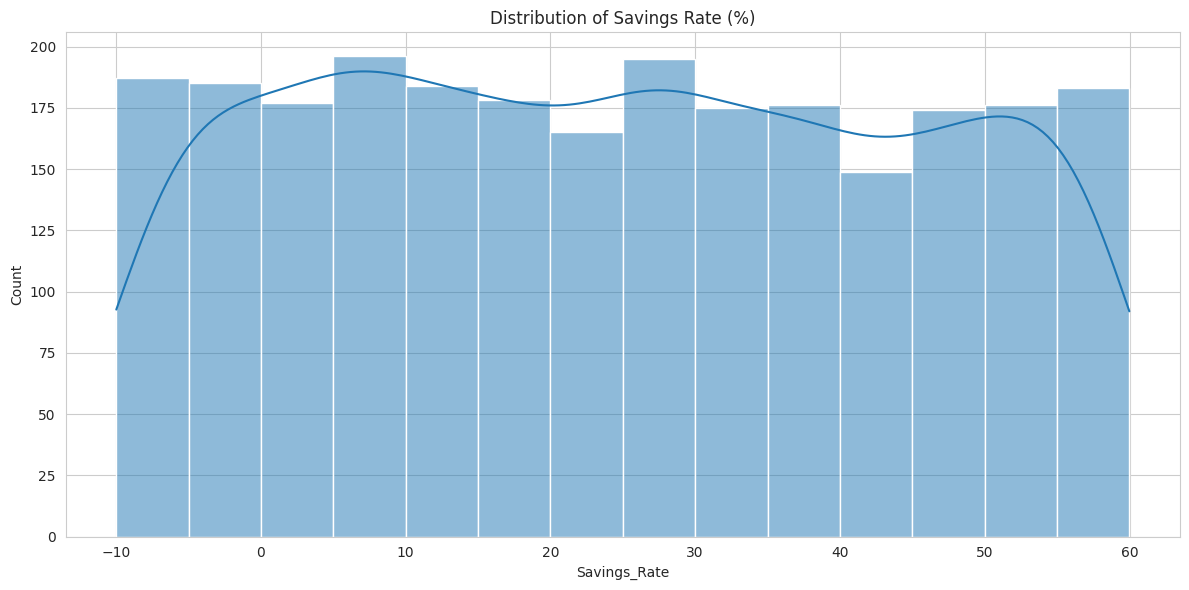

In [52]:
sns.histplot(df_clean['Savings_Rate'], kde=True)
plt.title('Distribution of Savings Rate (%)')
plt.tight_layout()
plt.show()

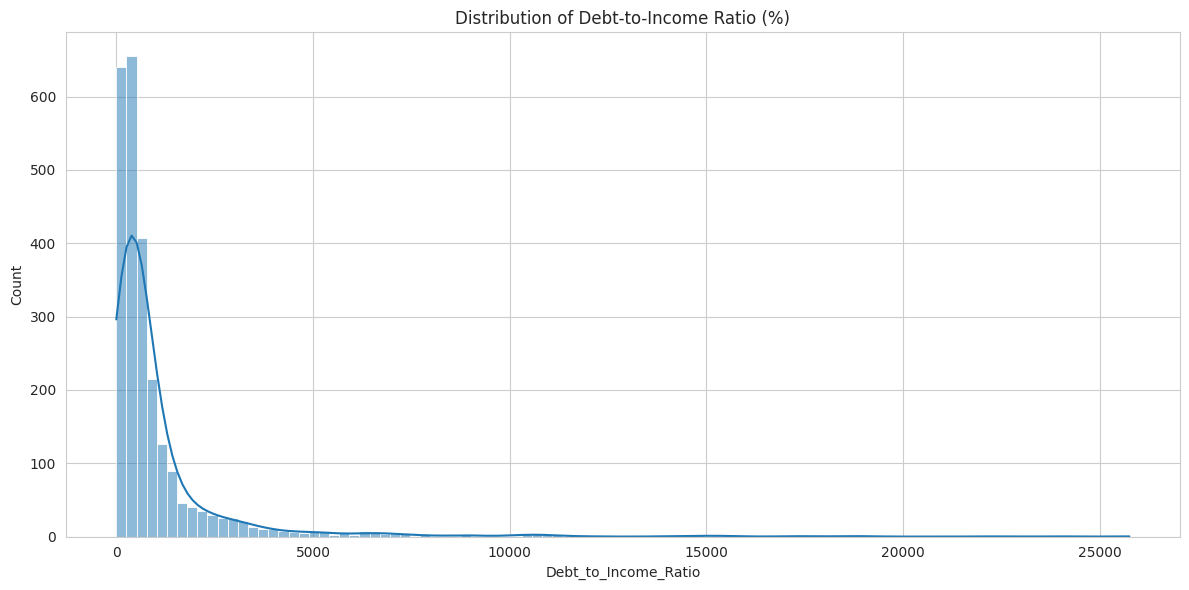

In [53]:
sns.histplot(df_clean['Debt_to_Income_Ratio'], kde=True)
plt.title('Distribution of Debt-to-Income Ratio (%)')
plt.tight_layout()
plt.show()

In [54]:
print(df_clean.shape)
df_clean.head()
df_clean.isnull().sum()

(2500, 20)


Household_ID            0
State                   0
District                0
Area                    0
Family_Size             0
Income                  0
Expenses                0
Savings                 0
Education               0
Occupation              0
Own_House               0
Vehicles                0
Electricity_Usage       0
Water_Source            0
Internet                0
Bank_Balance            0
Loan_Amount             0
Credit_Score            0
Savings_Rate            0
Debt_to_Income_Ratio    0
dtype: int64

## Summary of EDA Findings

India Household Dataset - EDA Summary:

1. Data Overview & Quality:
   - Dataset mein 2500 households aur 18 columns hain.
   - Sirf 'Education' column mein missing values the (494 rows, ~19.76%),
     unko mode (sabse common education level) se fill kar diya.
   - Duplicate rows check kiye - agar the to hata diye.

2. Univariate Analysis:
   - Income, Expenses, Savings, Loan_Amount jaise columns ki spread
     histogram aur boxplot se dekhi.
   - State-wise household count mein top 15 states dikhaye.
   - Education, Occupation, Own_House, Internet, Water_Source ki
     categories count kiye.

3. Outlier Detection:
   - IQR aur Z-score dono methods se Income, Expenses, Savings,
     Loan_Amount, Credit_Score mein outliers check kiye.

4. Bivariate Analysis:
   - Income Education level ke hisaab se kaafi vary karta hai
     (higher education -> generally higher income).
   - State-wise Income spread bhi different hai.
   - Occupation ke hisaab se bhi Income mein pattern dikhta hai.
   - House ownership ka Credit Score ke saath bhi thoda relation dikha.

5. Correlation & Pivot Analysis:
   - Correlation matrix se numeric columns ke beech relationship dekhi
     (jaise Income aur Savings/Loan_Amount).
   - Pivot table se State x Education ke hisaab se average Income nikala.

6. Derived Features:
   - Savings_Rate (Savings / Income %) aur Debt_to_Income_Ratio
     (Loan_Amount / Income %) naye columns banaye taaki financial
     health better samajh aaye.

Overall, ye EDA household ki income, expenses, savings aur demographics
ke patterns samajhne mein help karta hai - jaise ki education aur
occupation ka income par kya asar hai, aur kaunse states/areas mein
financial profile alag hai.